Found Synapse note file: E:\resp_test_data\subj11-250227-070534\Notes.txt
read from t=0s to t=309.84s


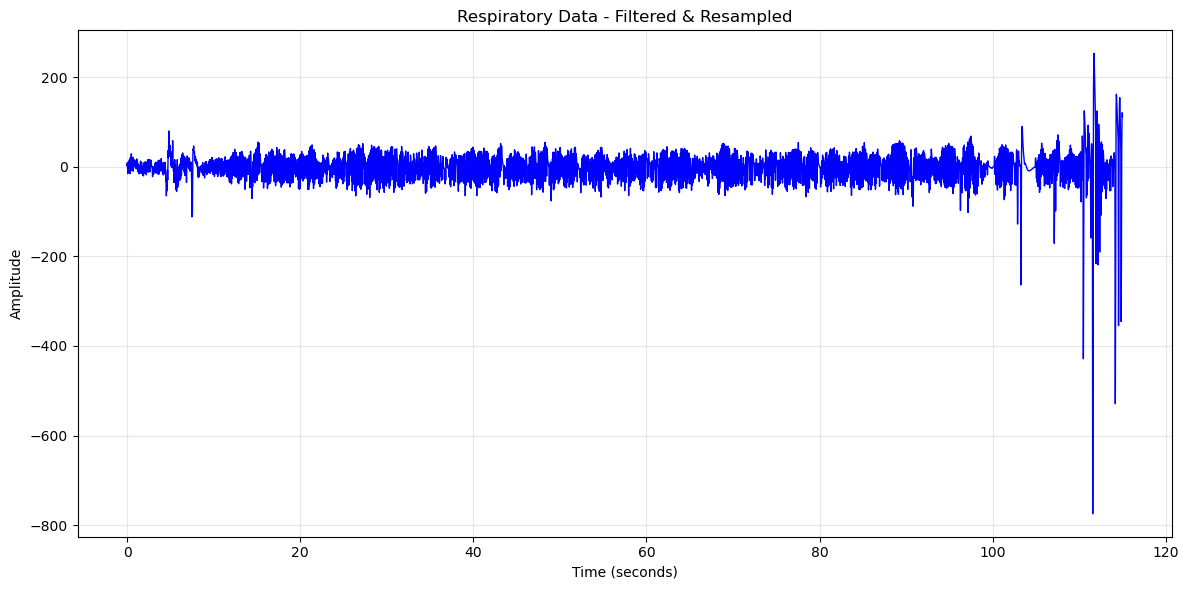

Estimated Breathing Rate: 471.57 breaths per minute
Estimated Breathing Rate: 7.86 breaths per second


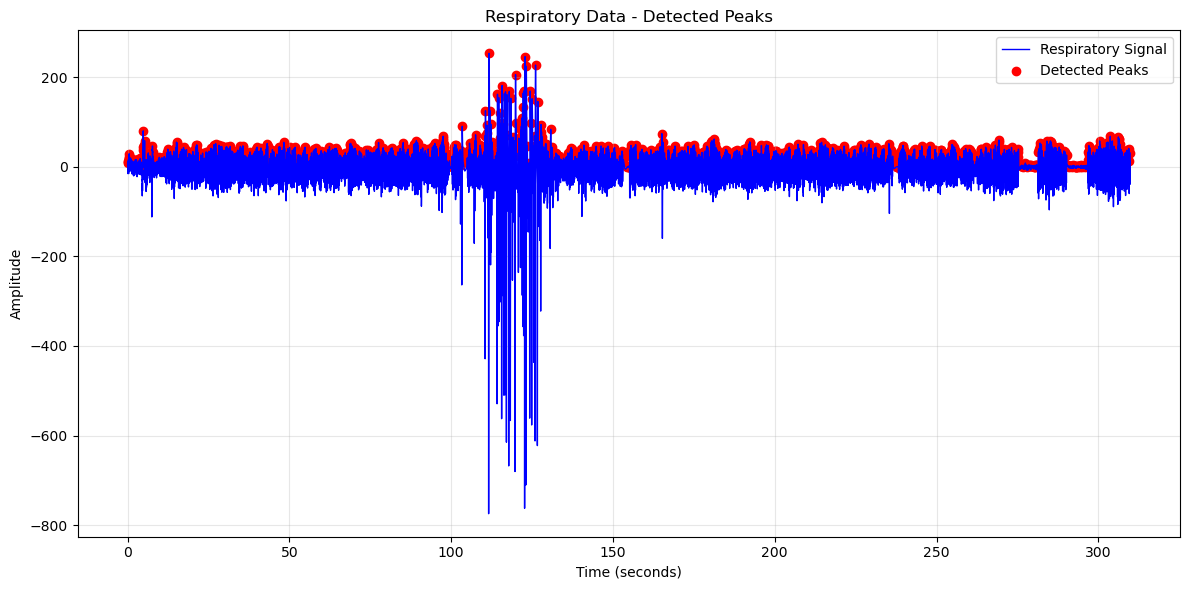

c:\Users\sjs93\OneDrive\Documents\GitHub\respiratory_pilot\resp_plotting.py:55: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(5, 2, figsize=figsize)


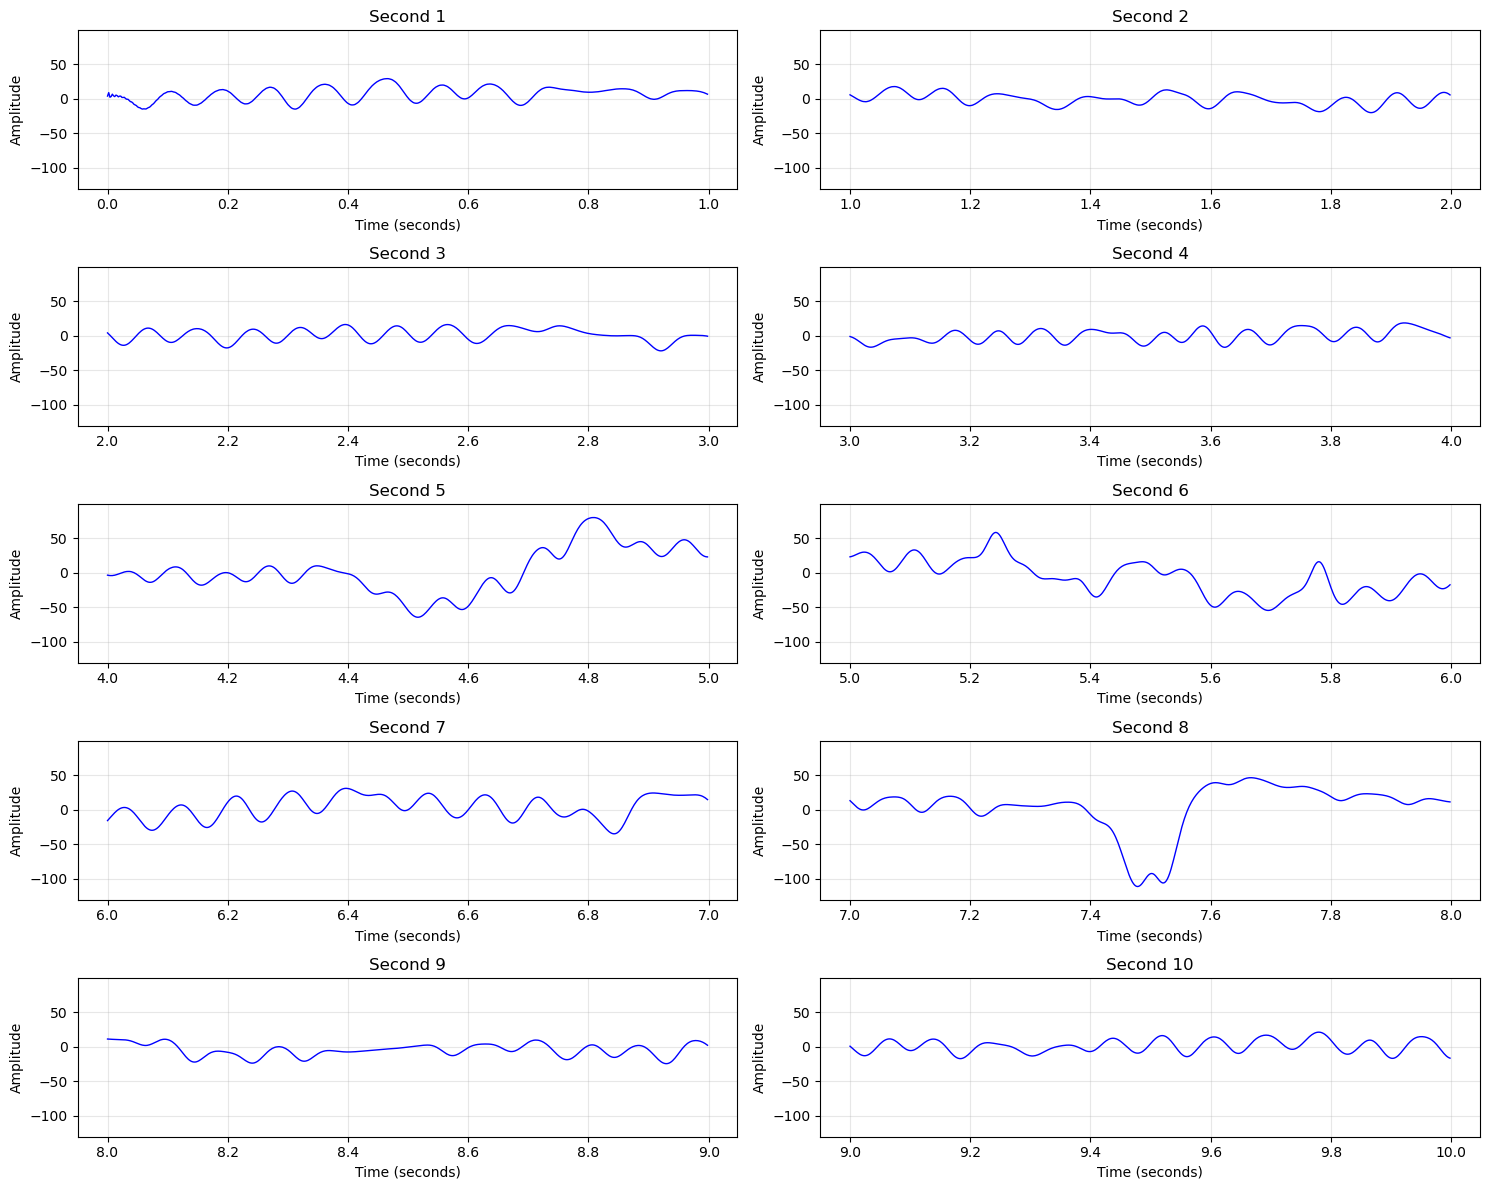

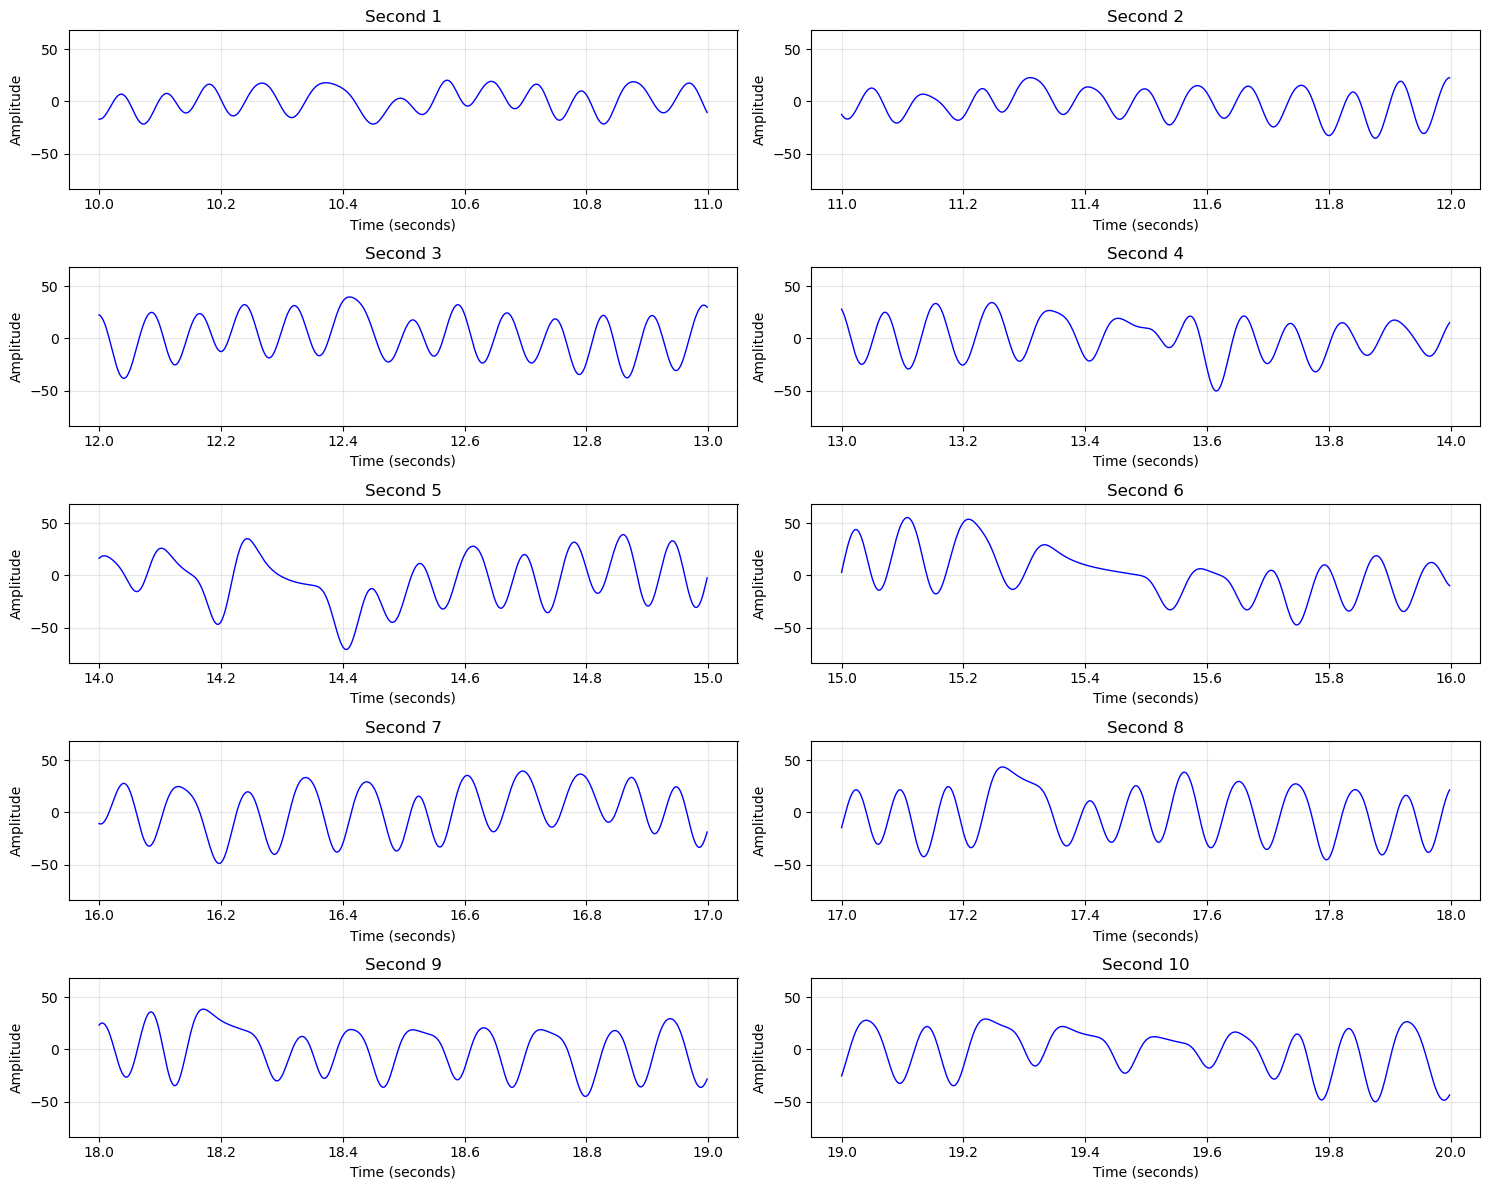

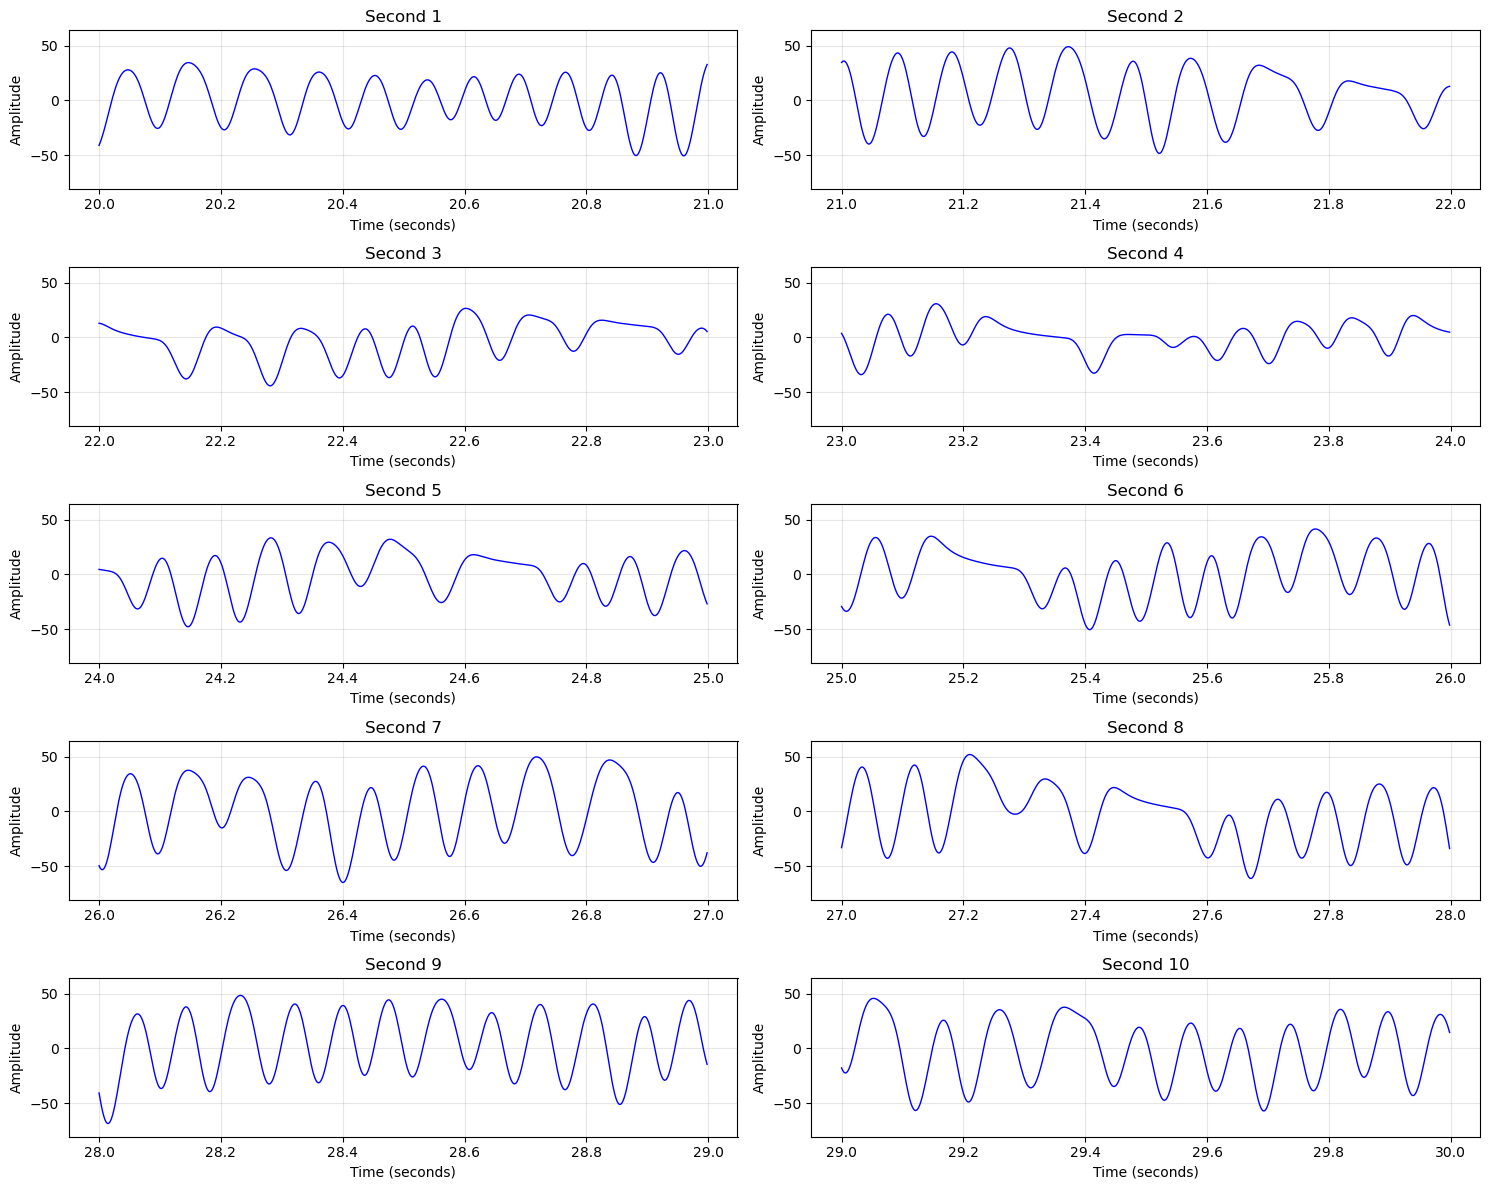

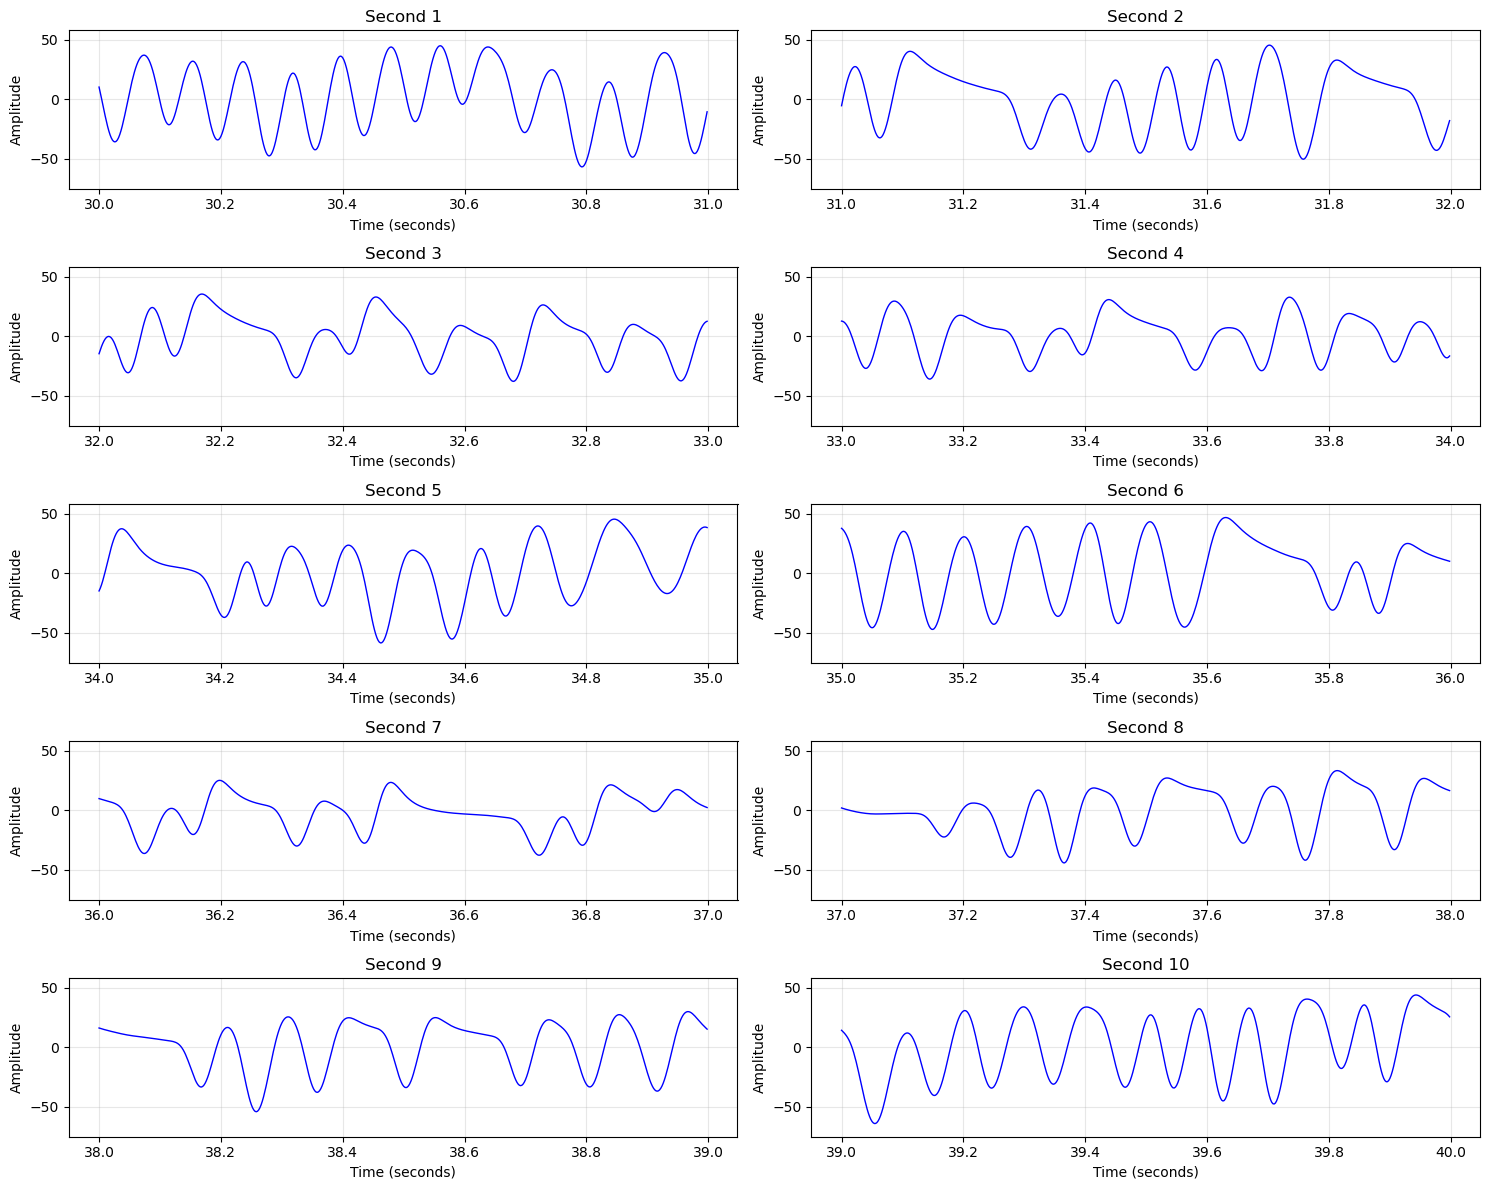

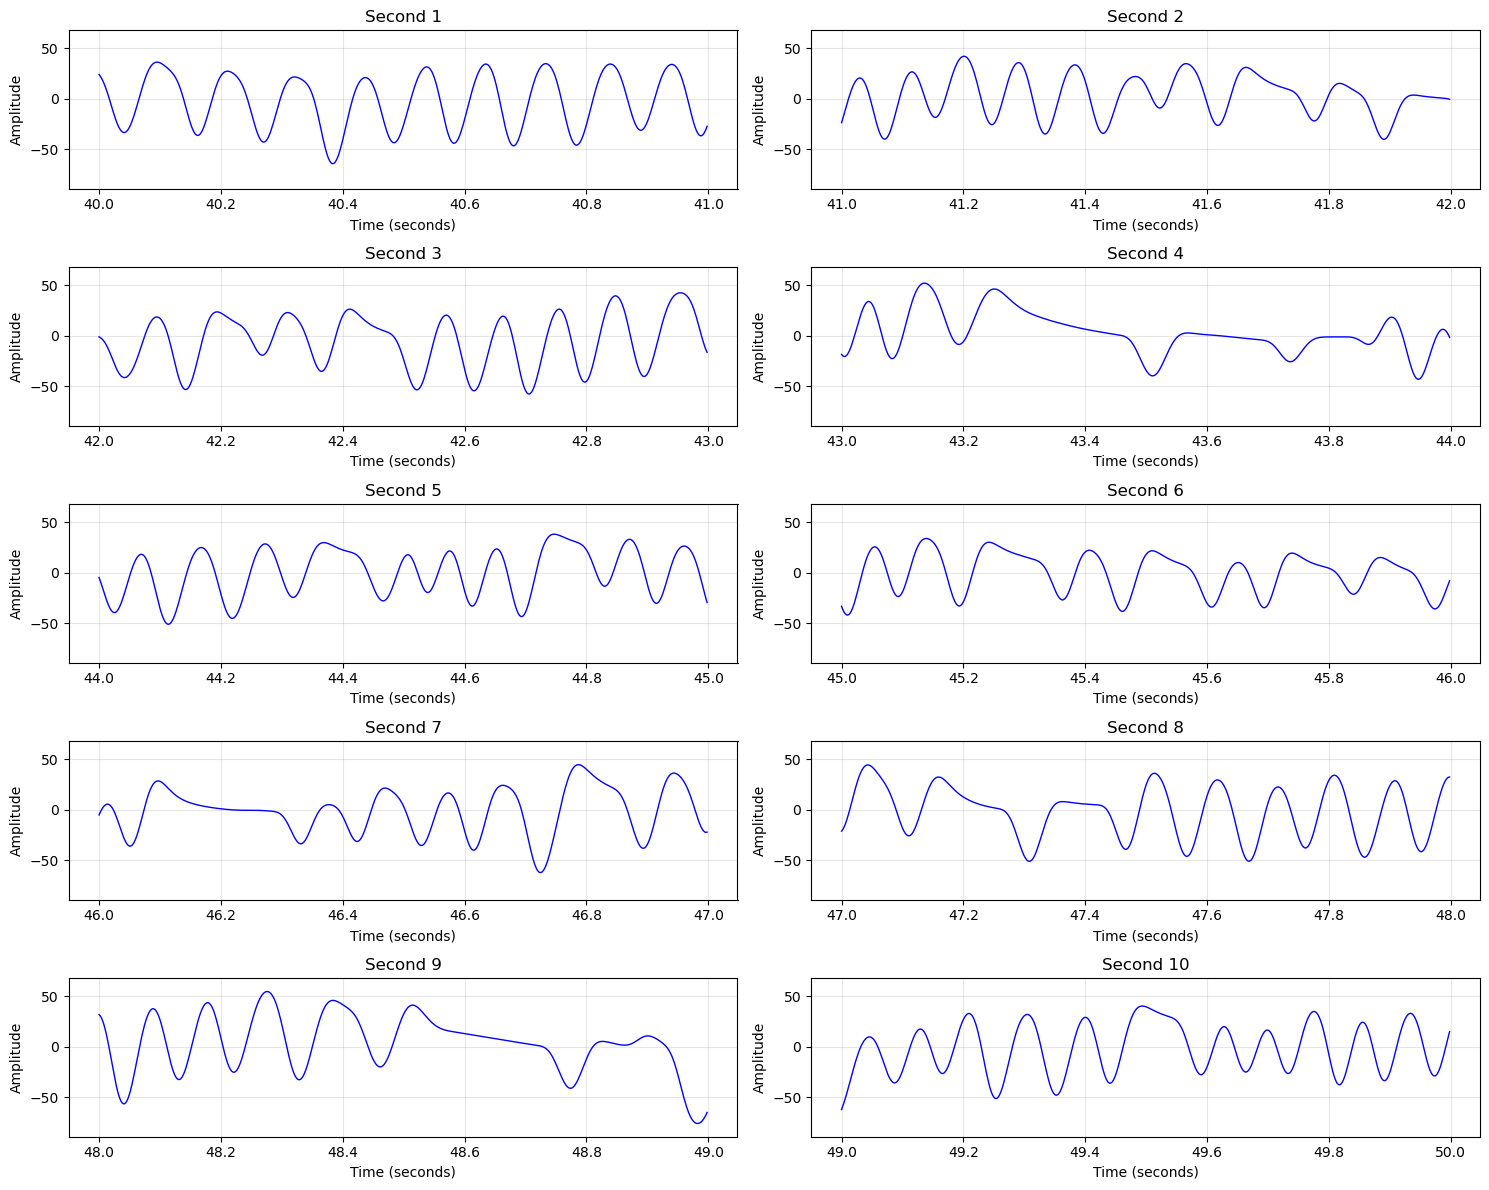

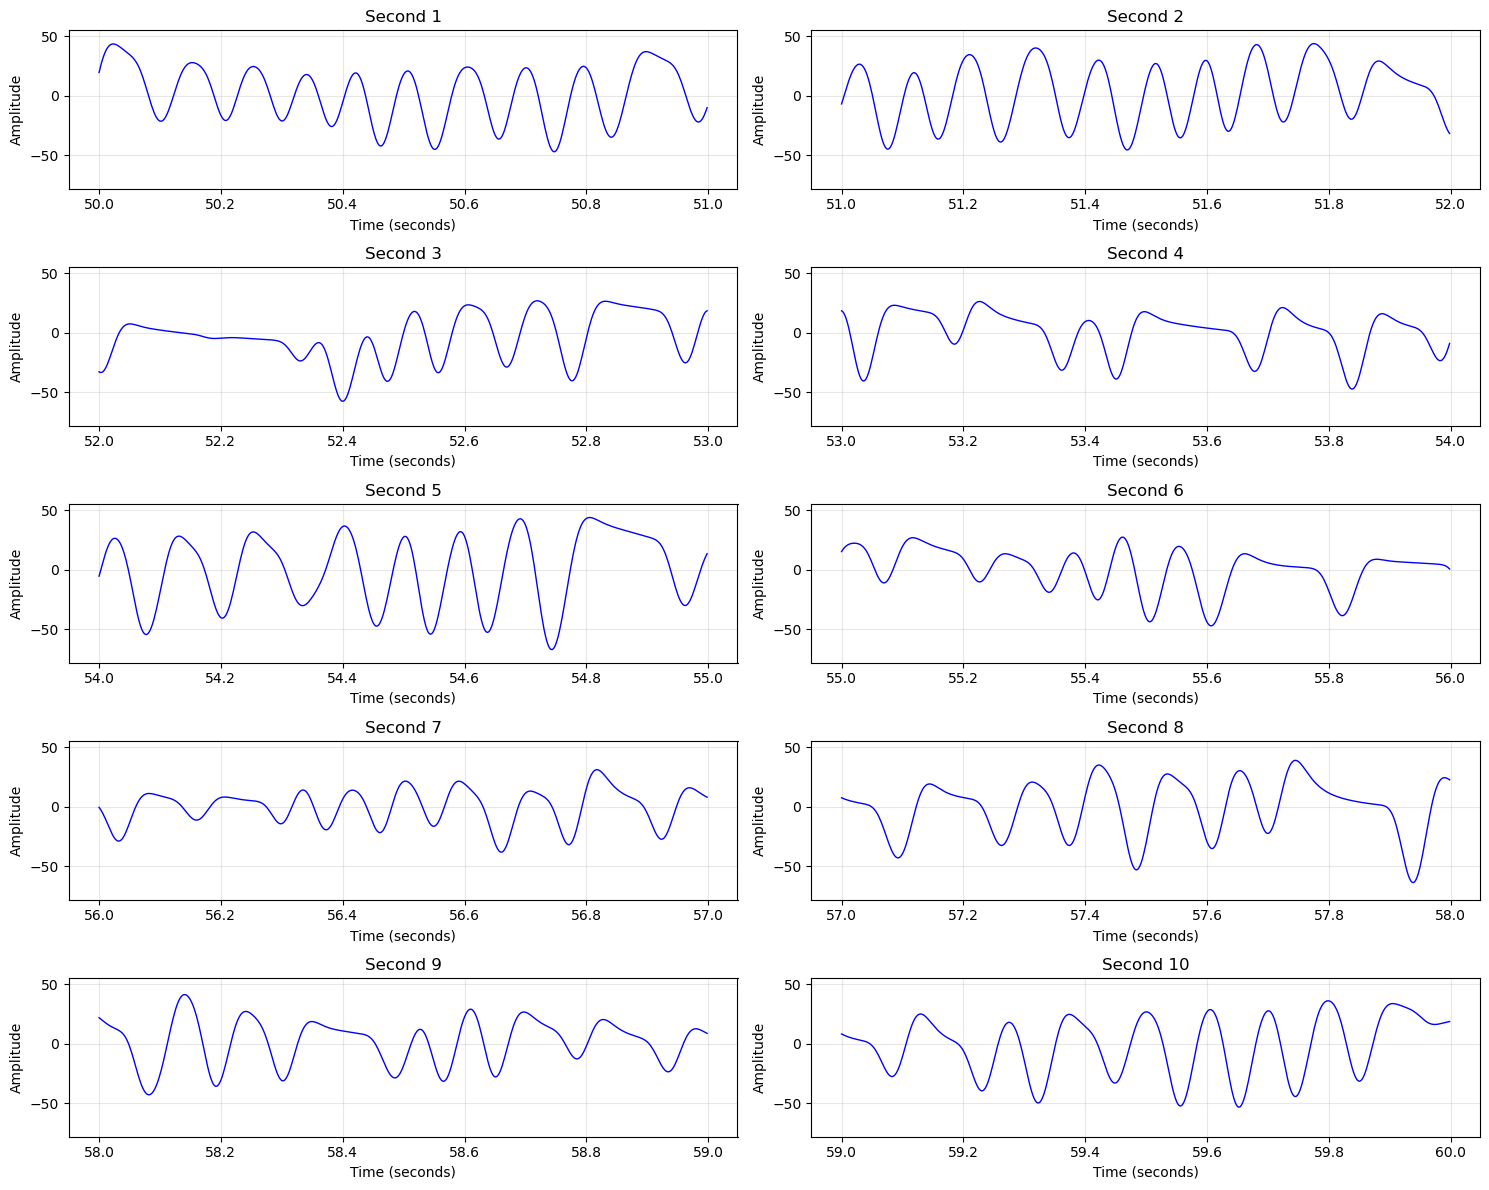

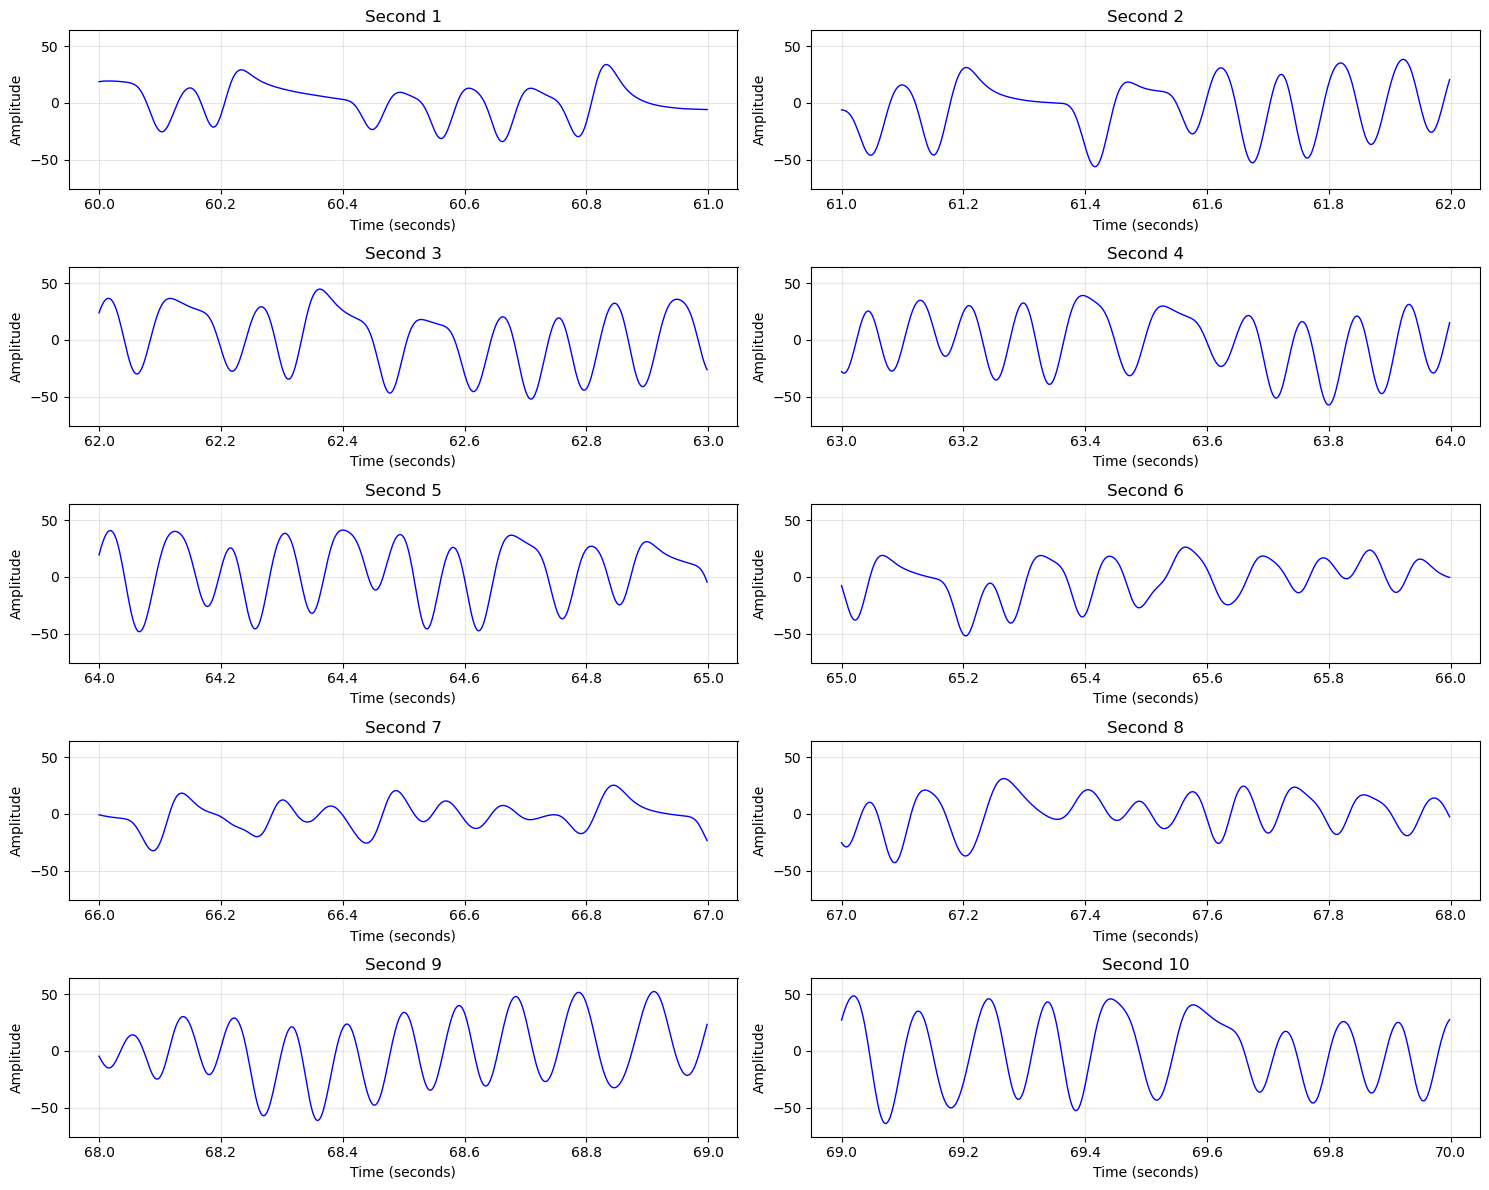

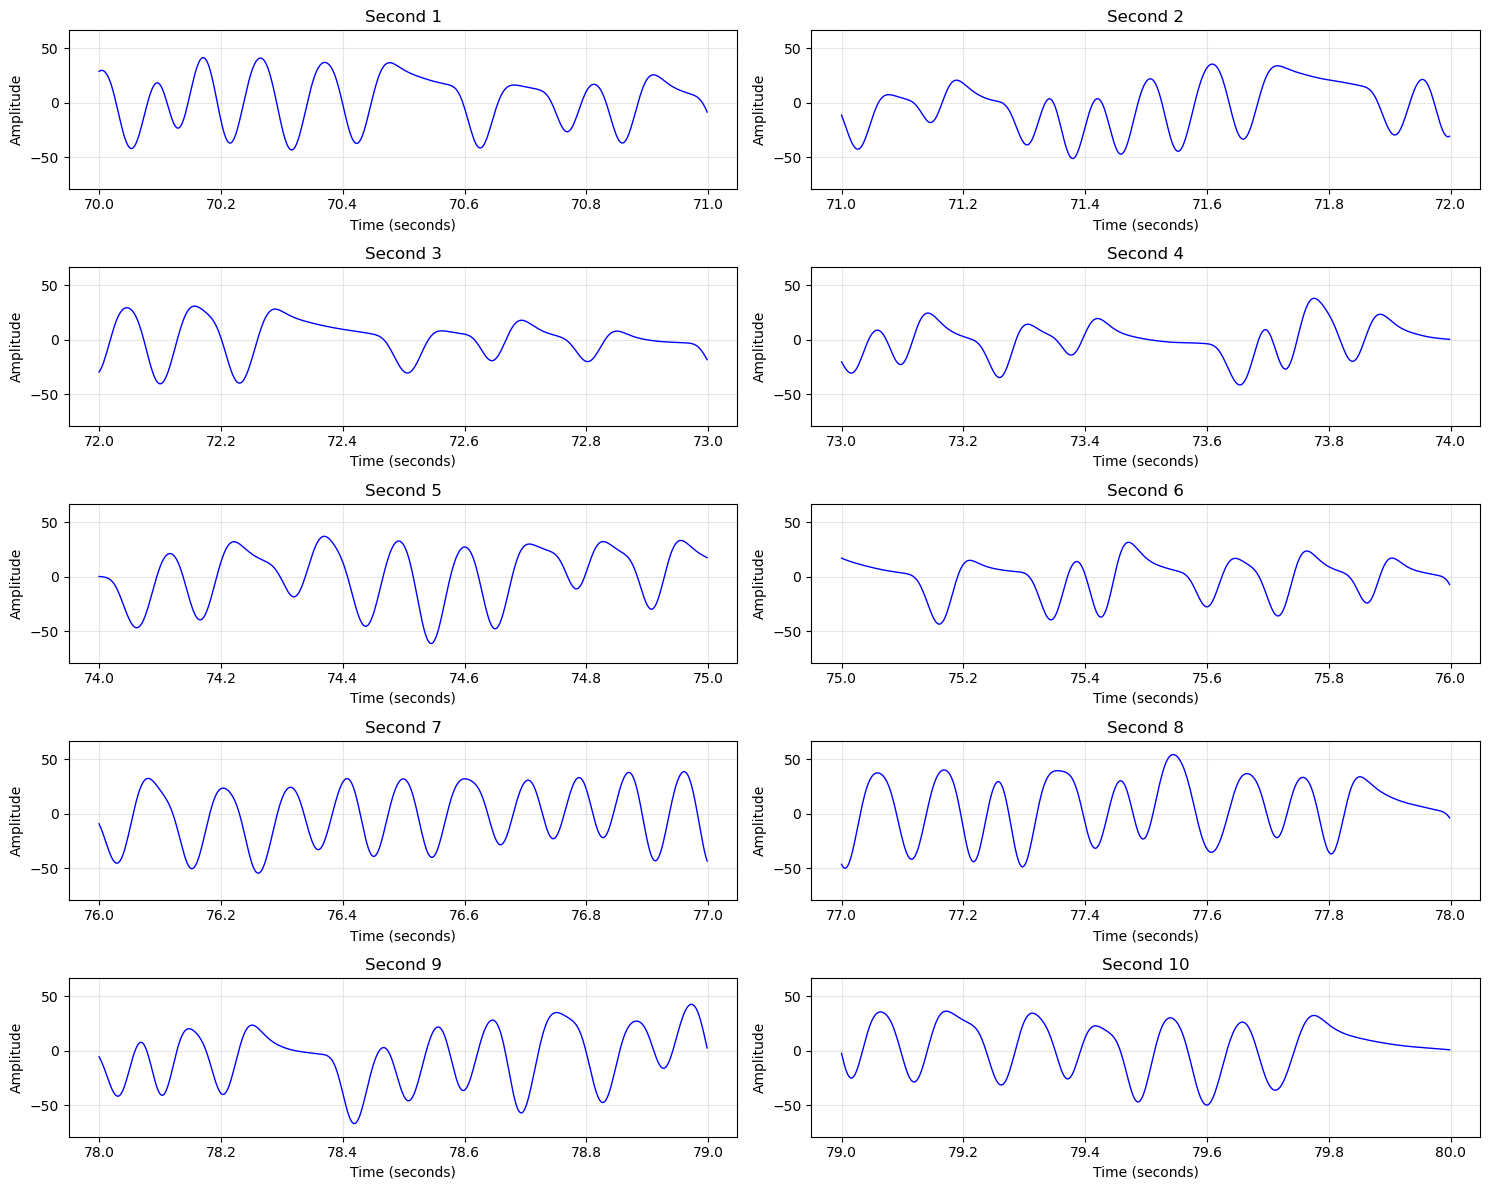

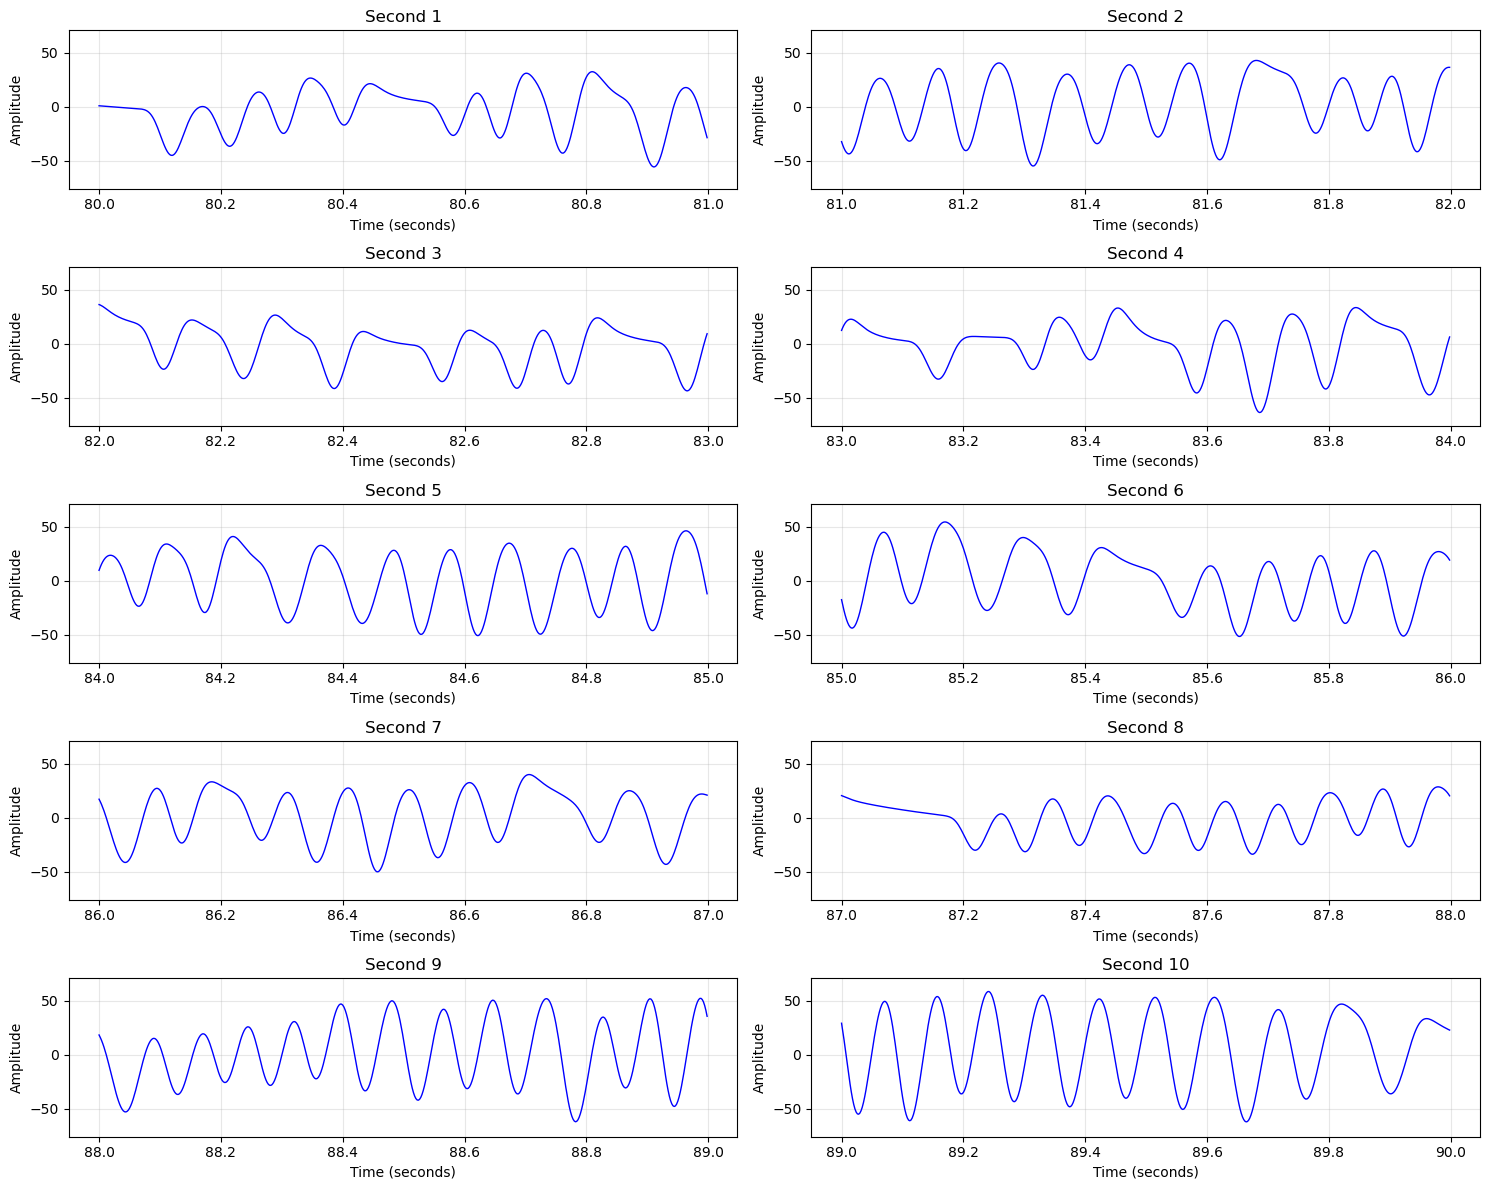

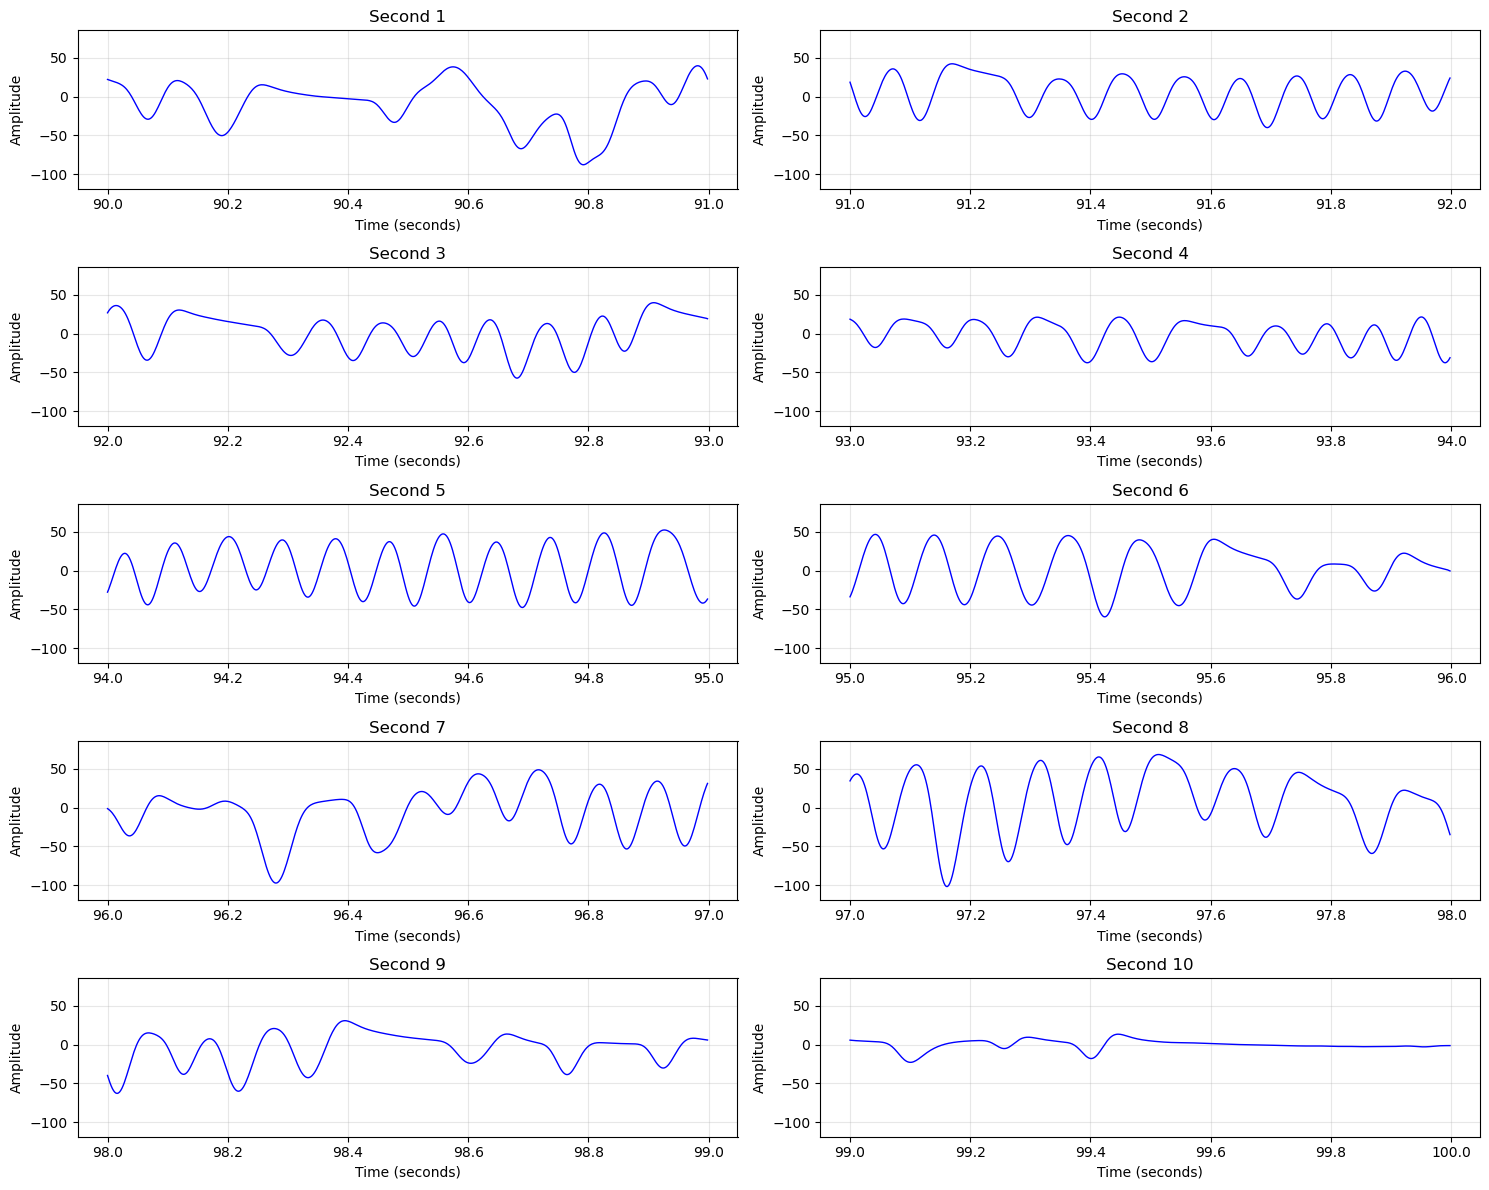

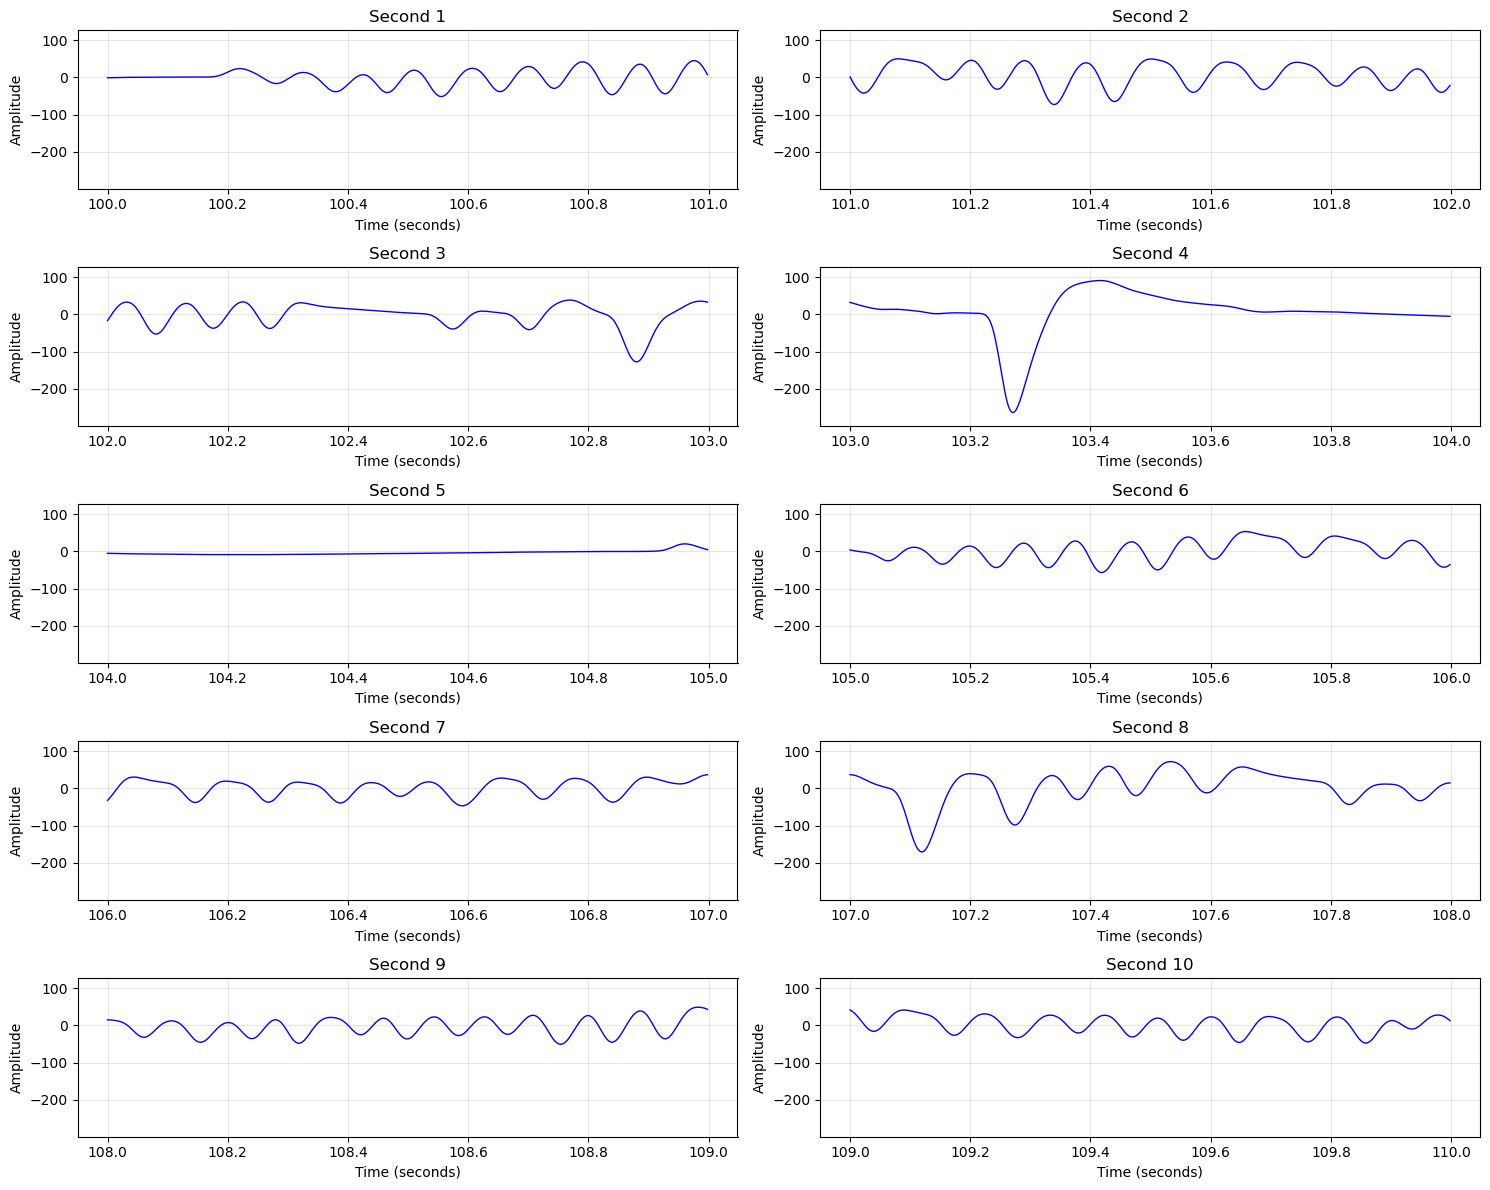

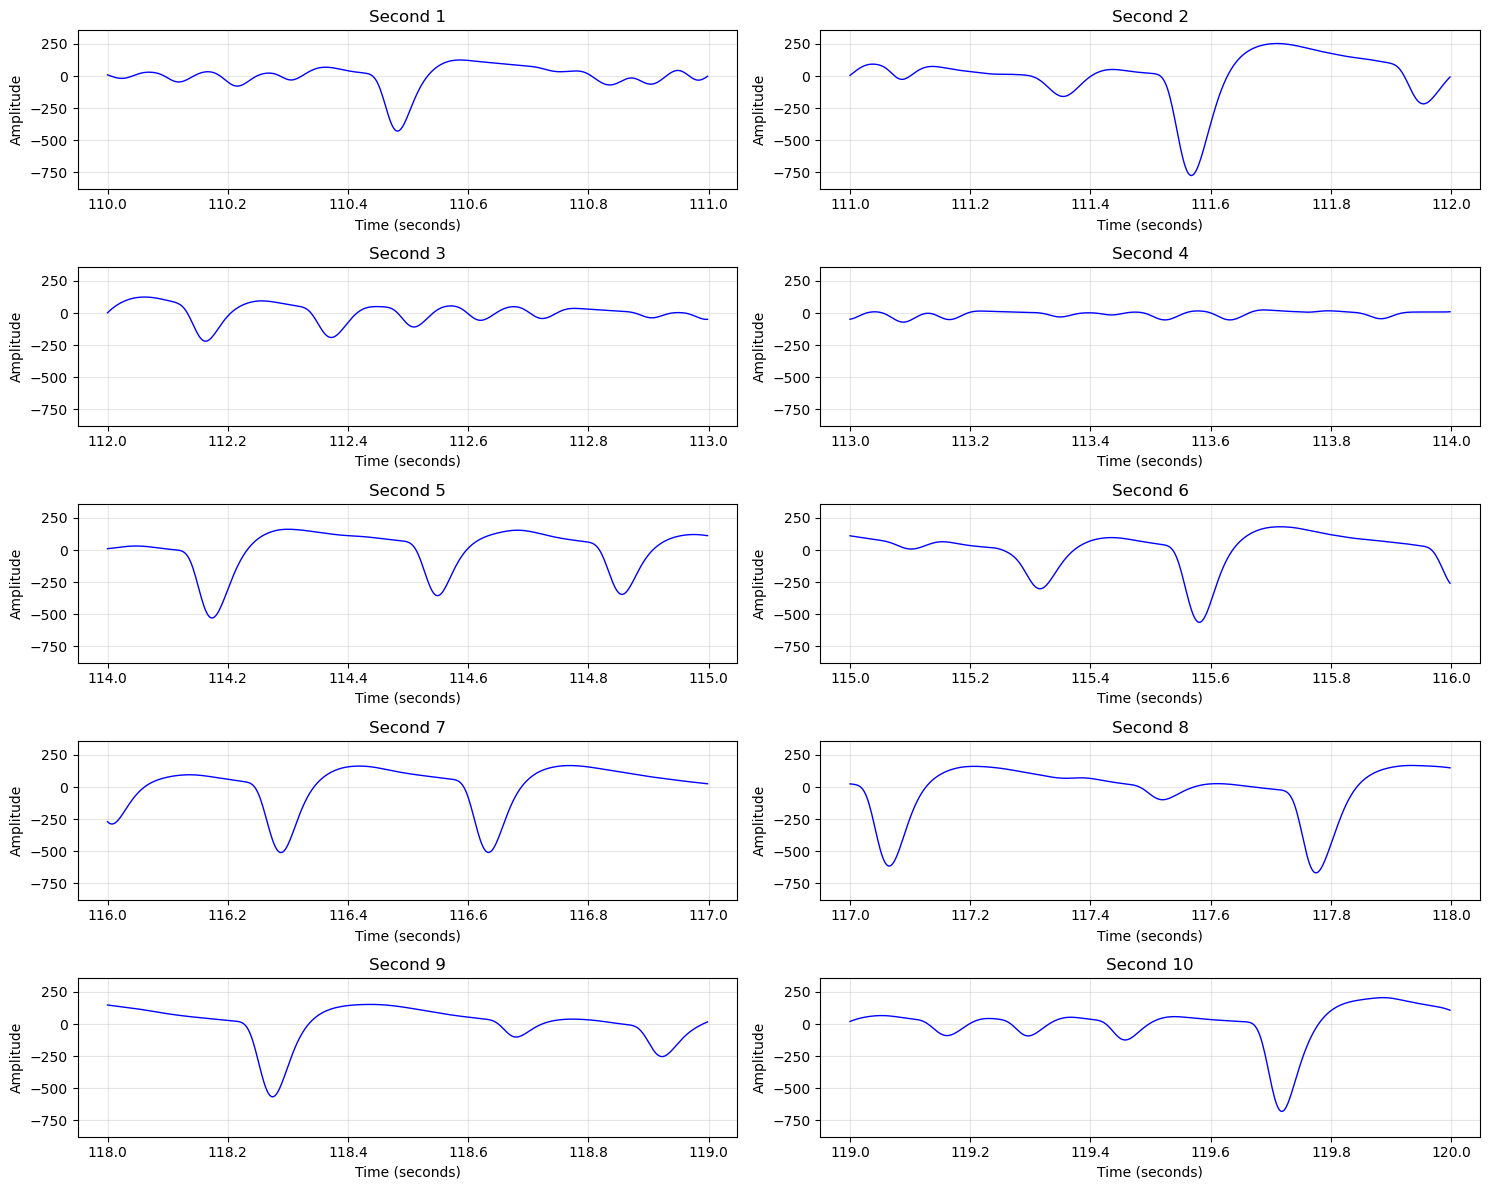

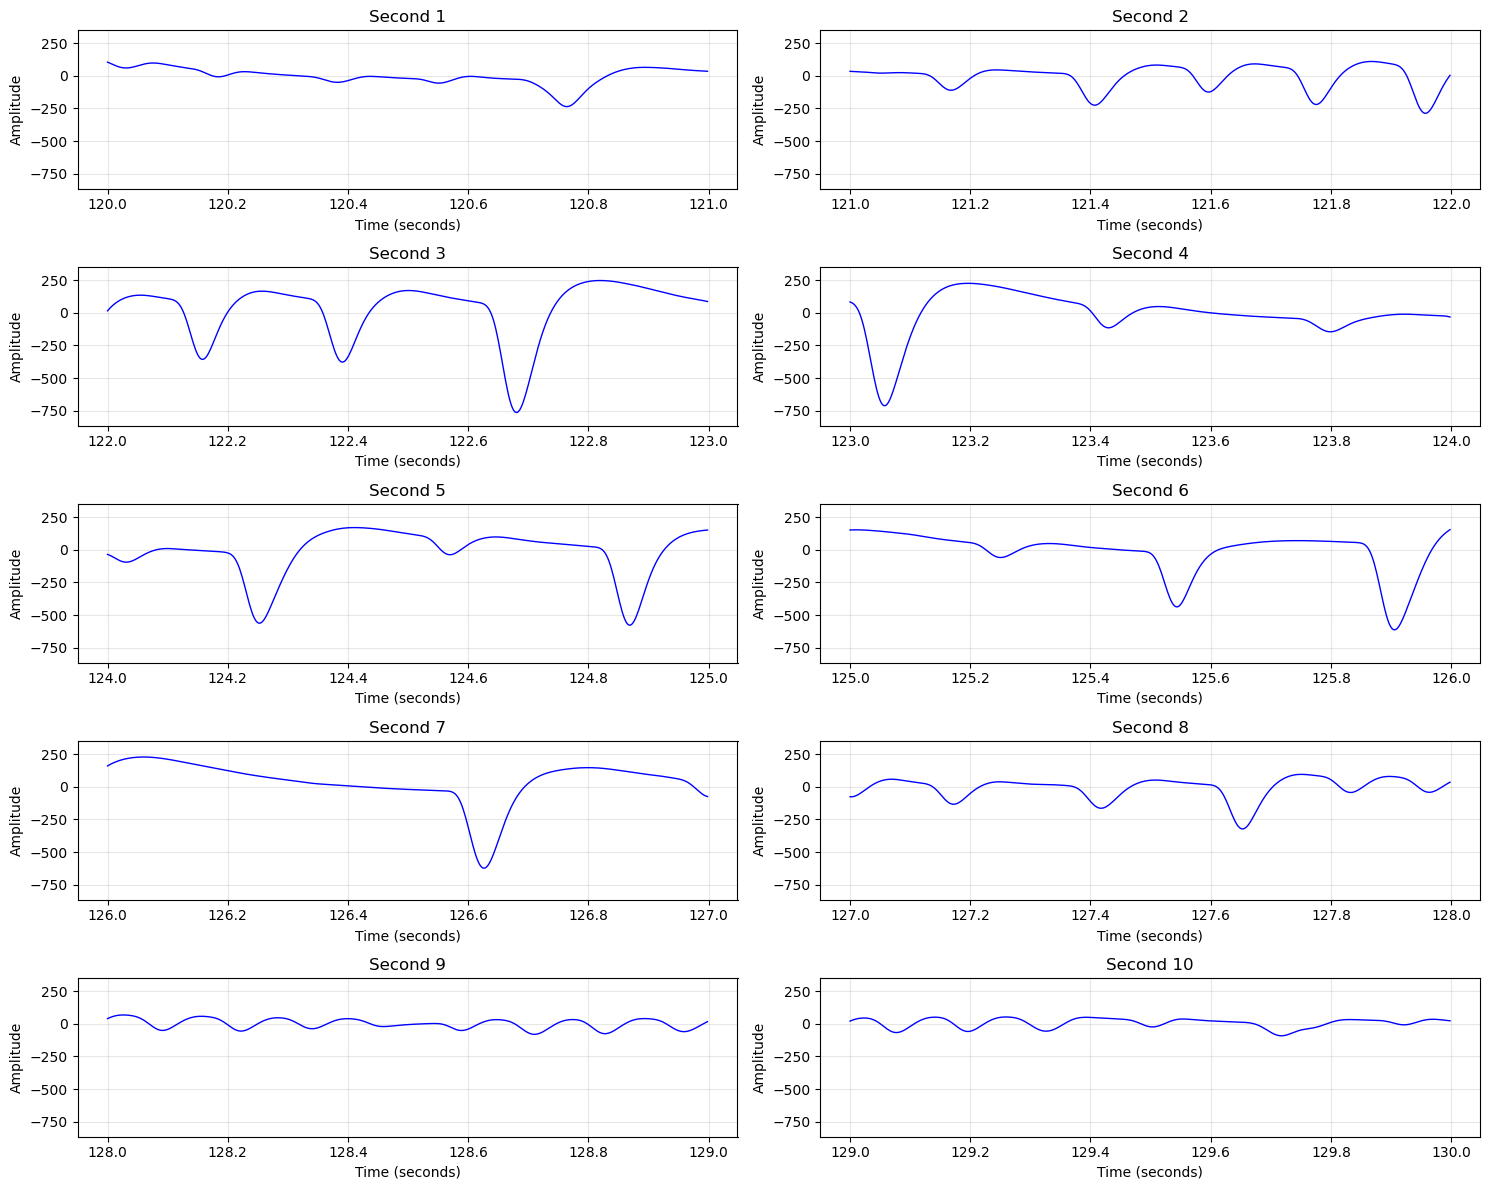

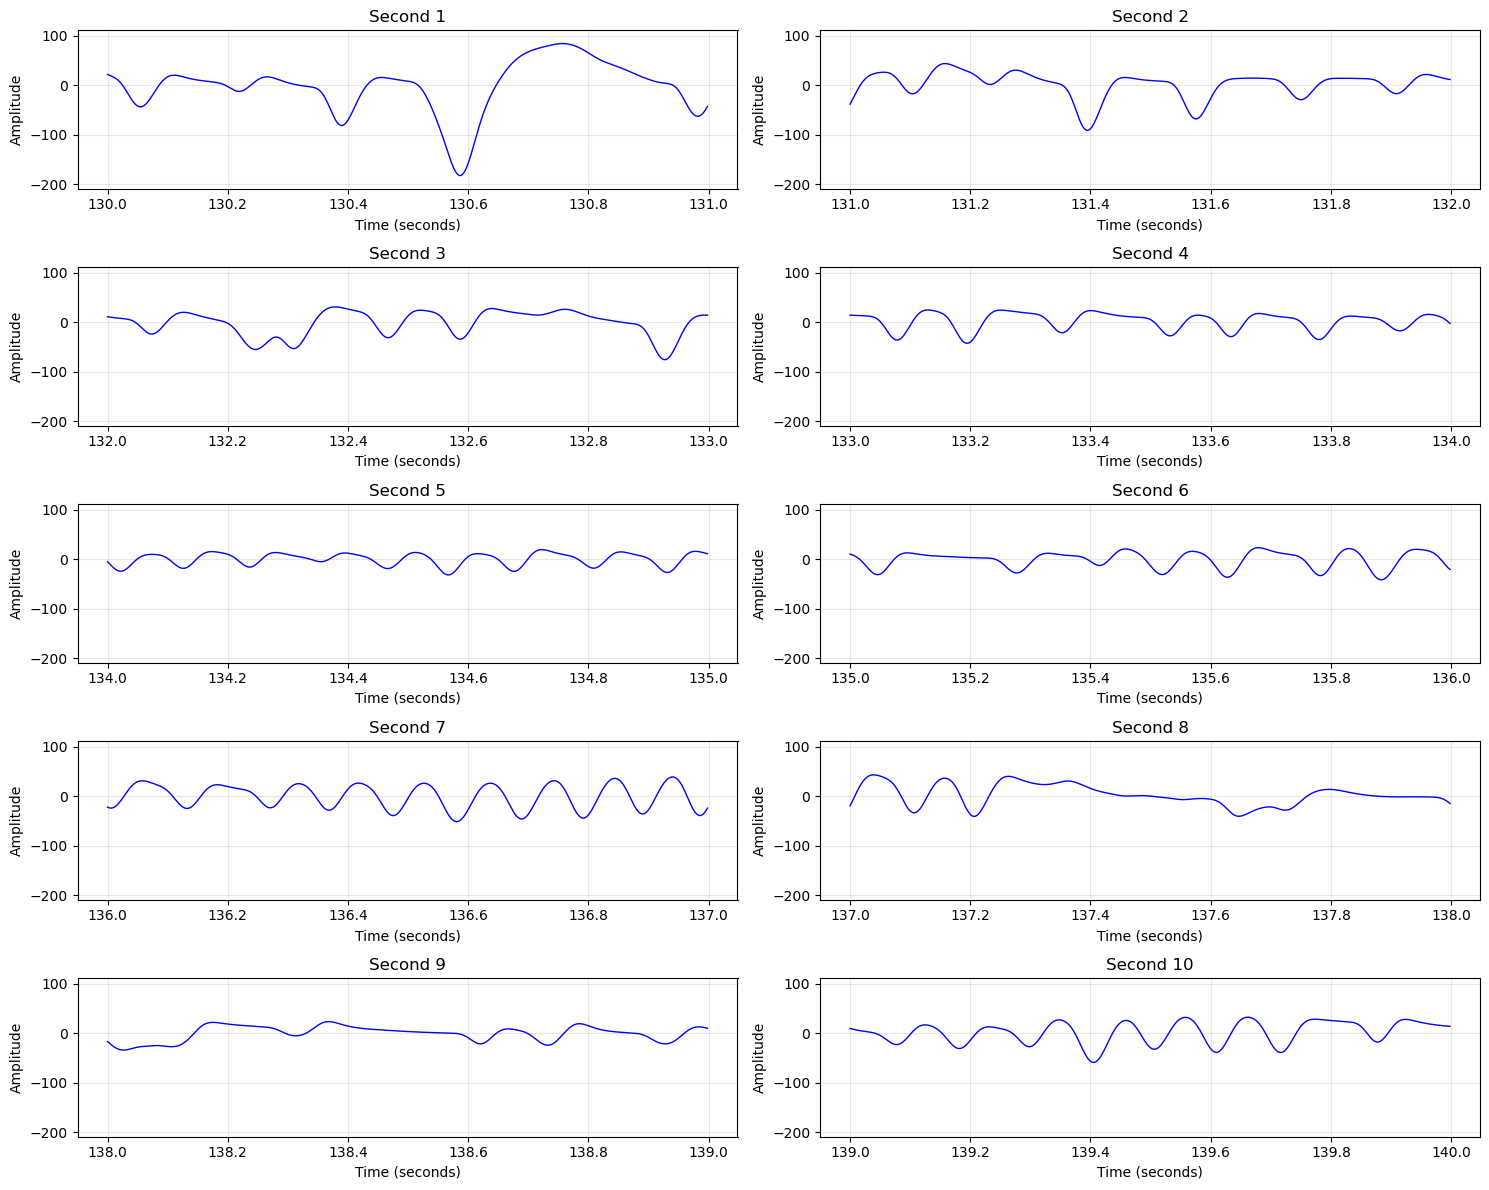

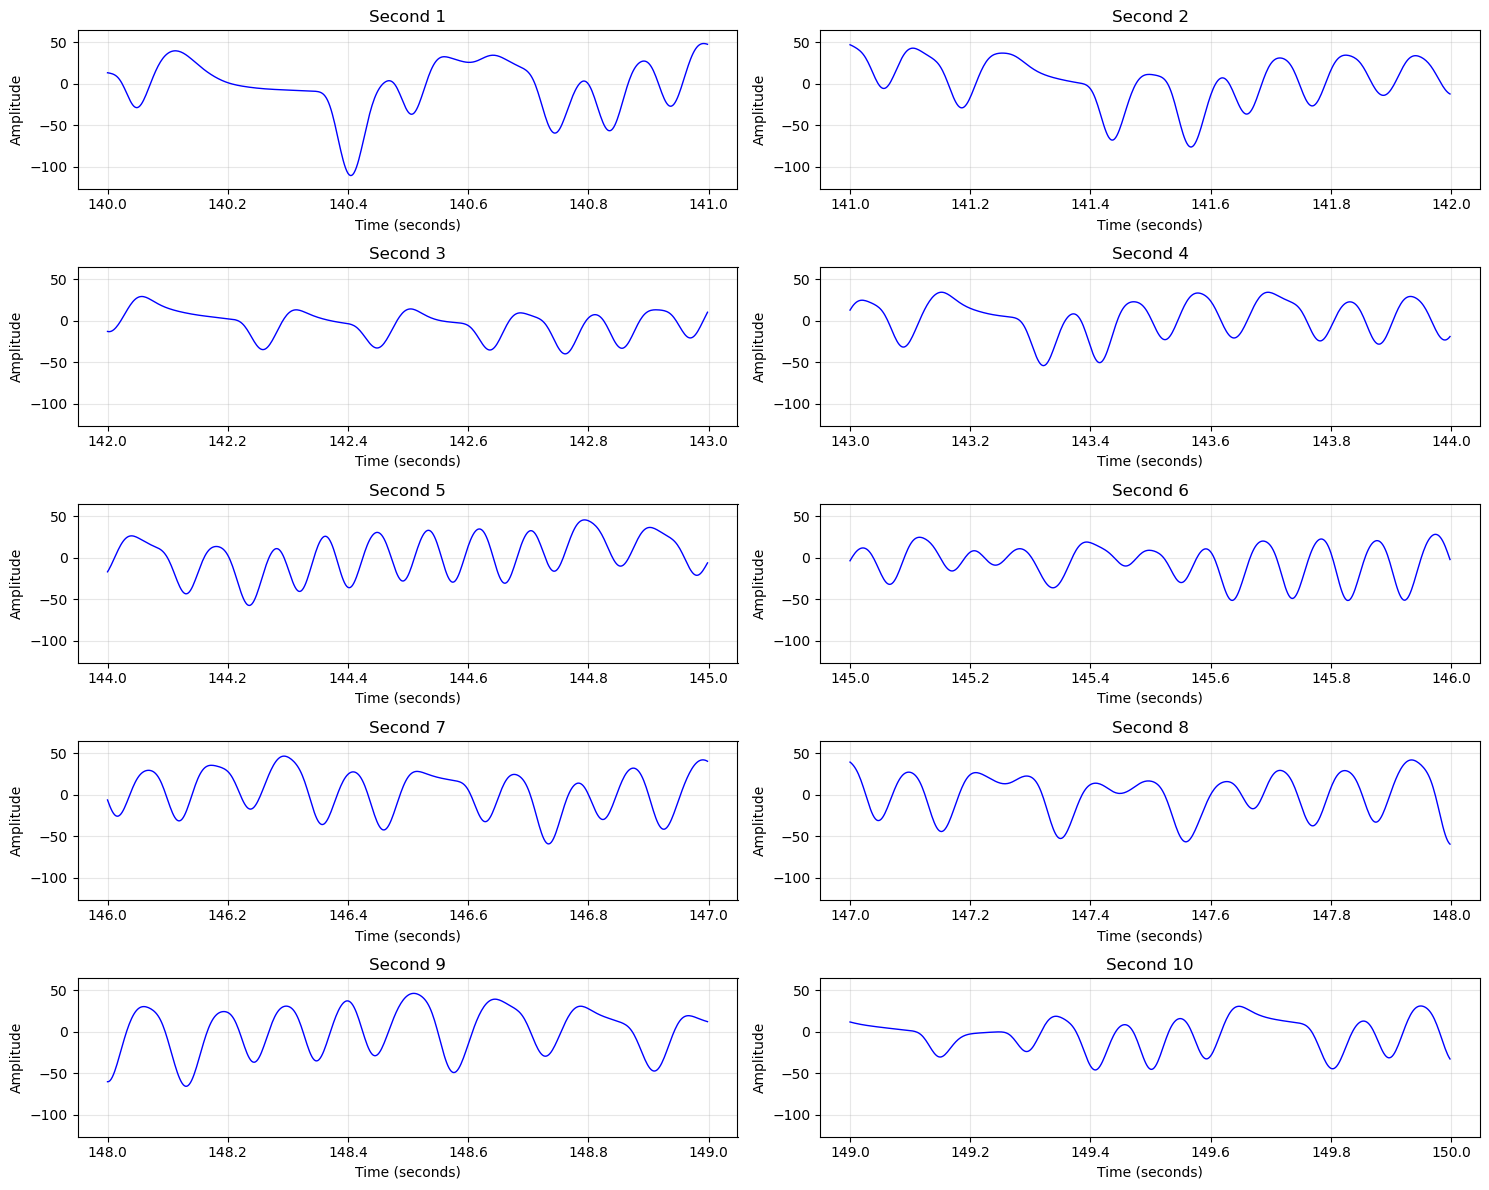

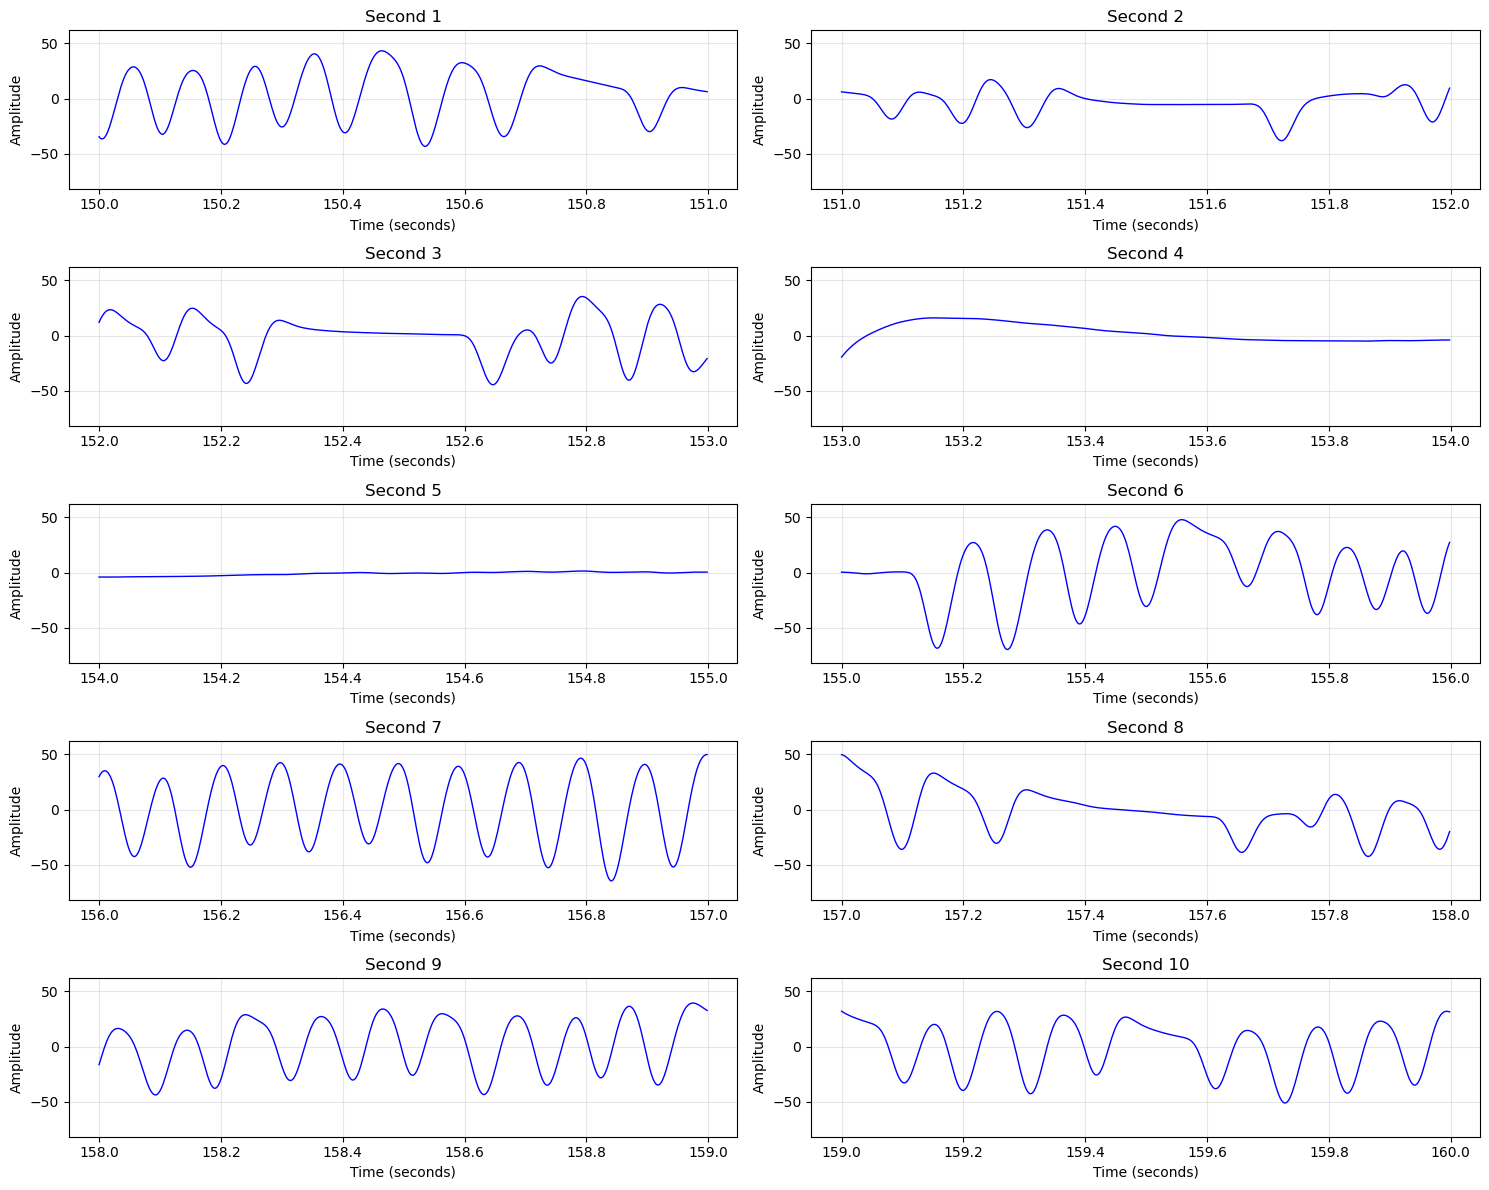

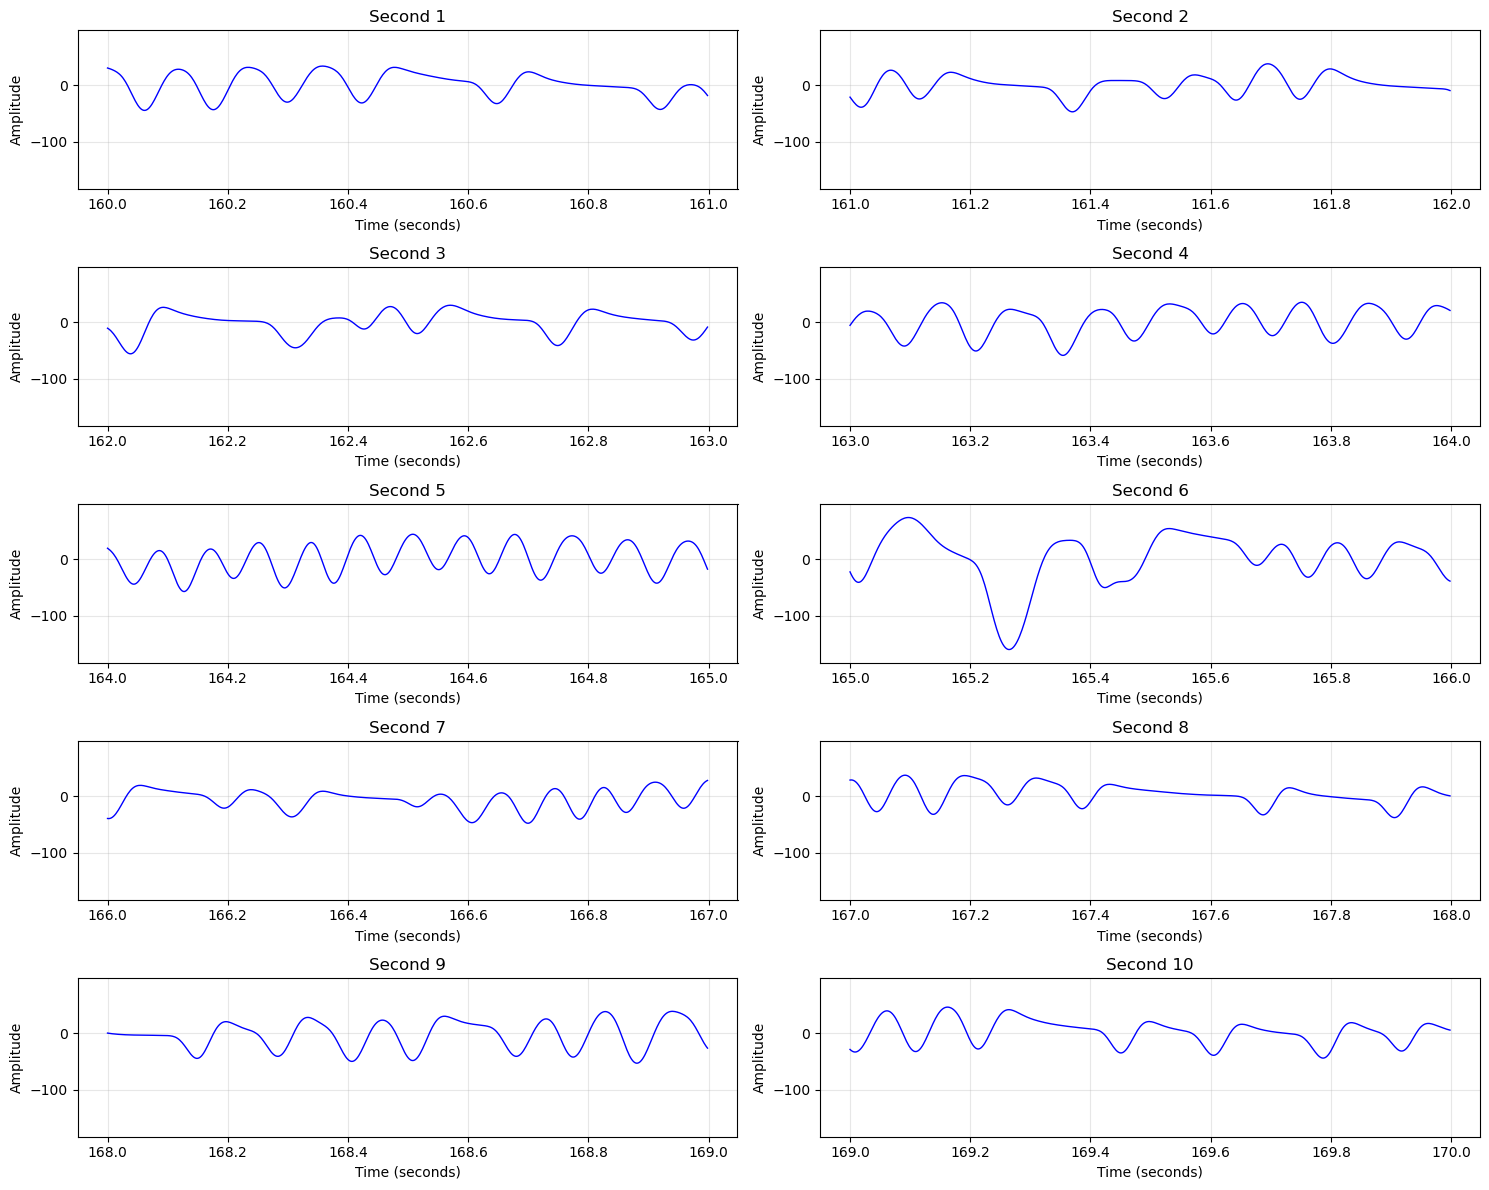

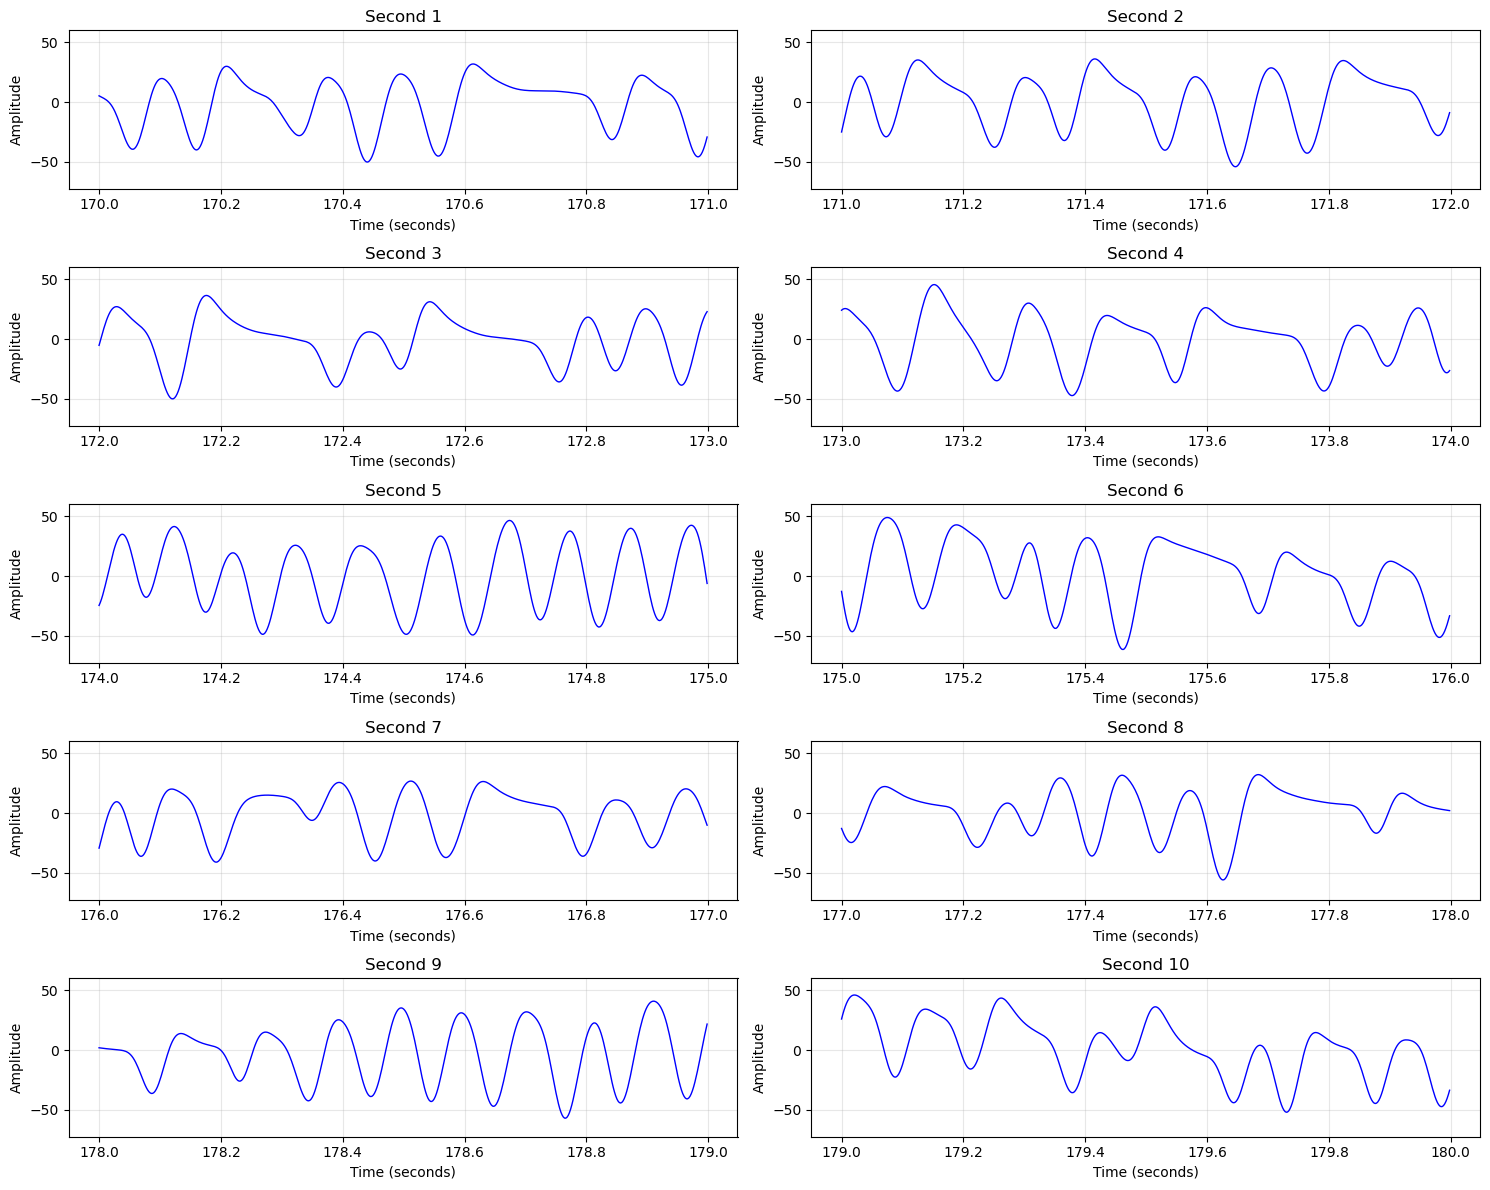

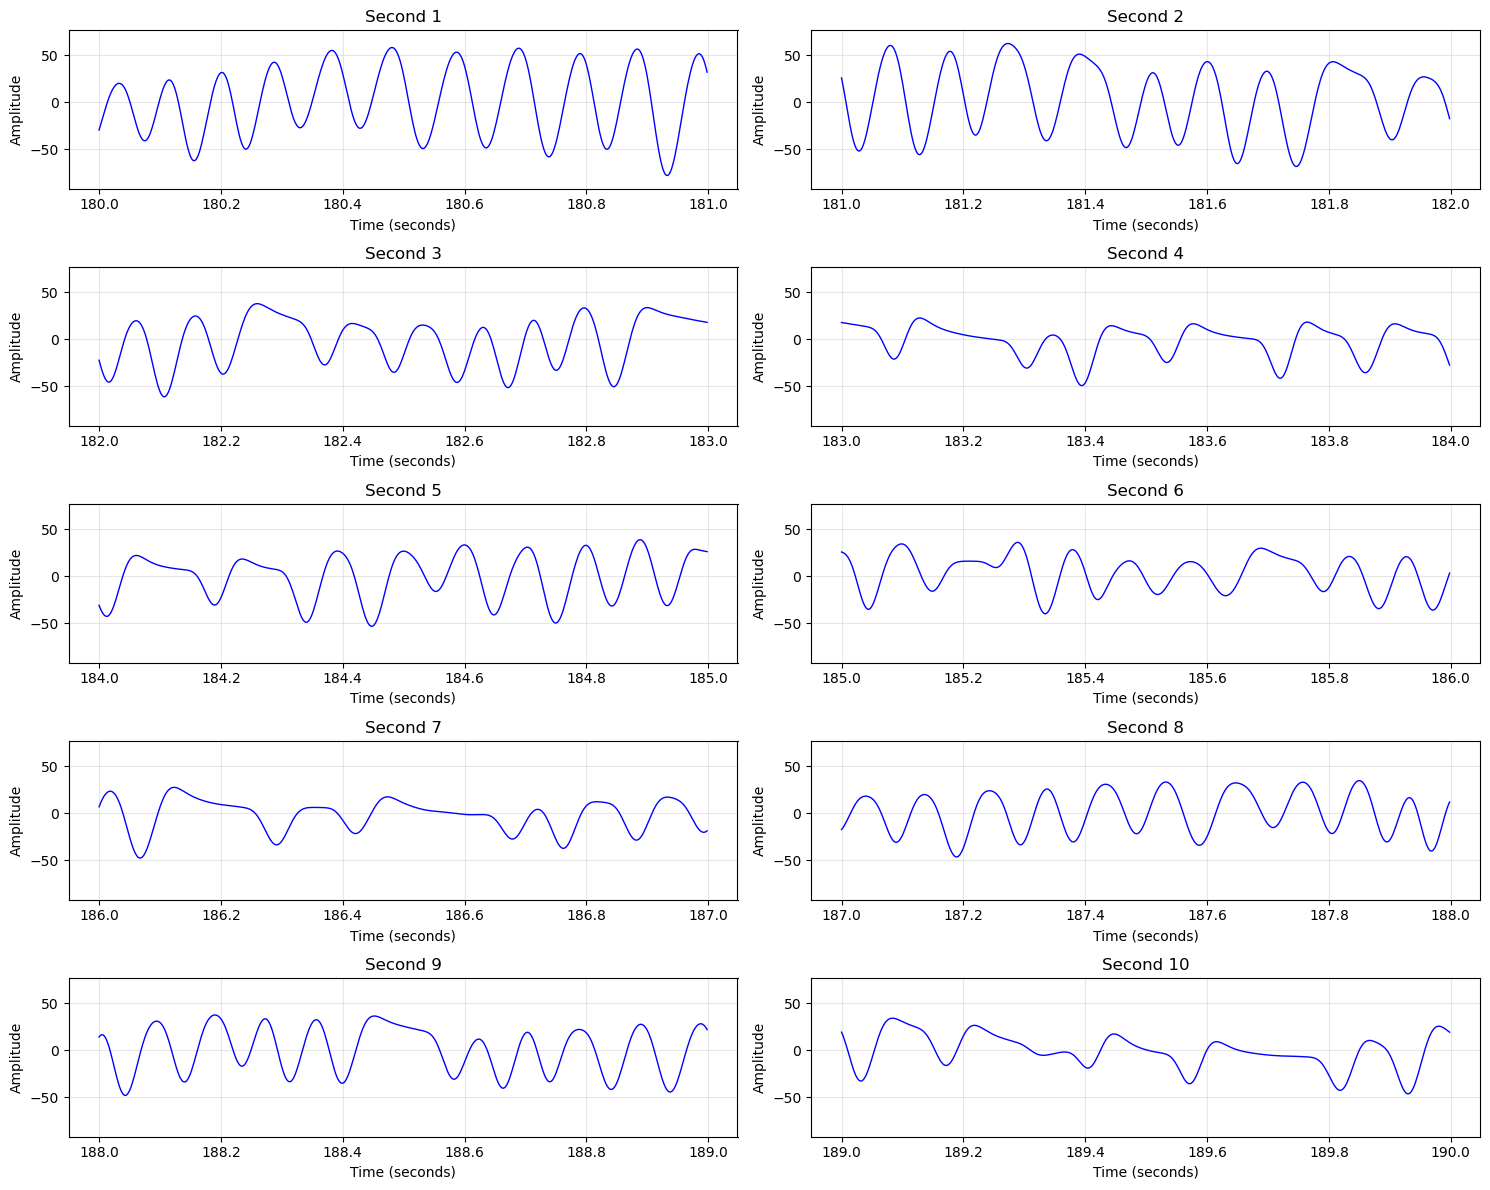

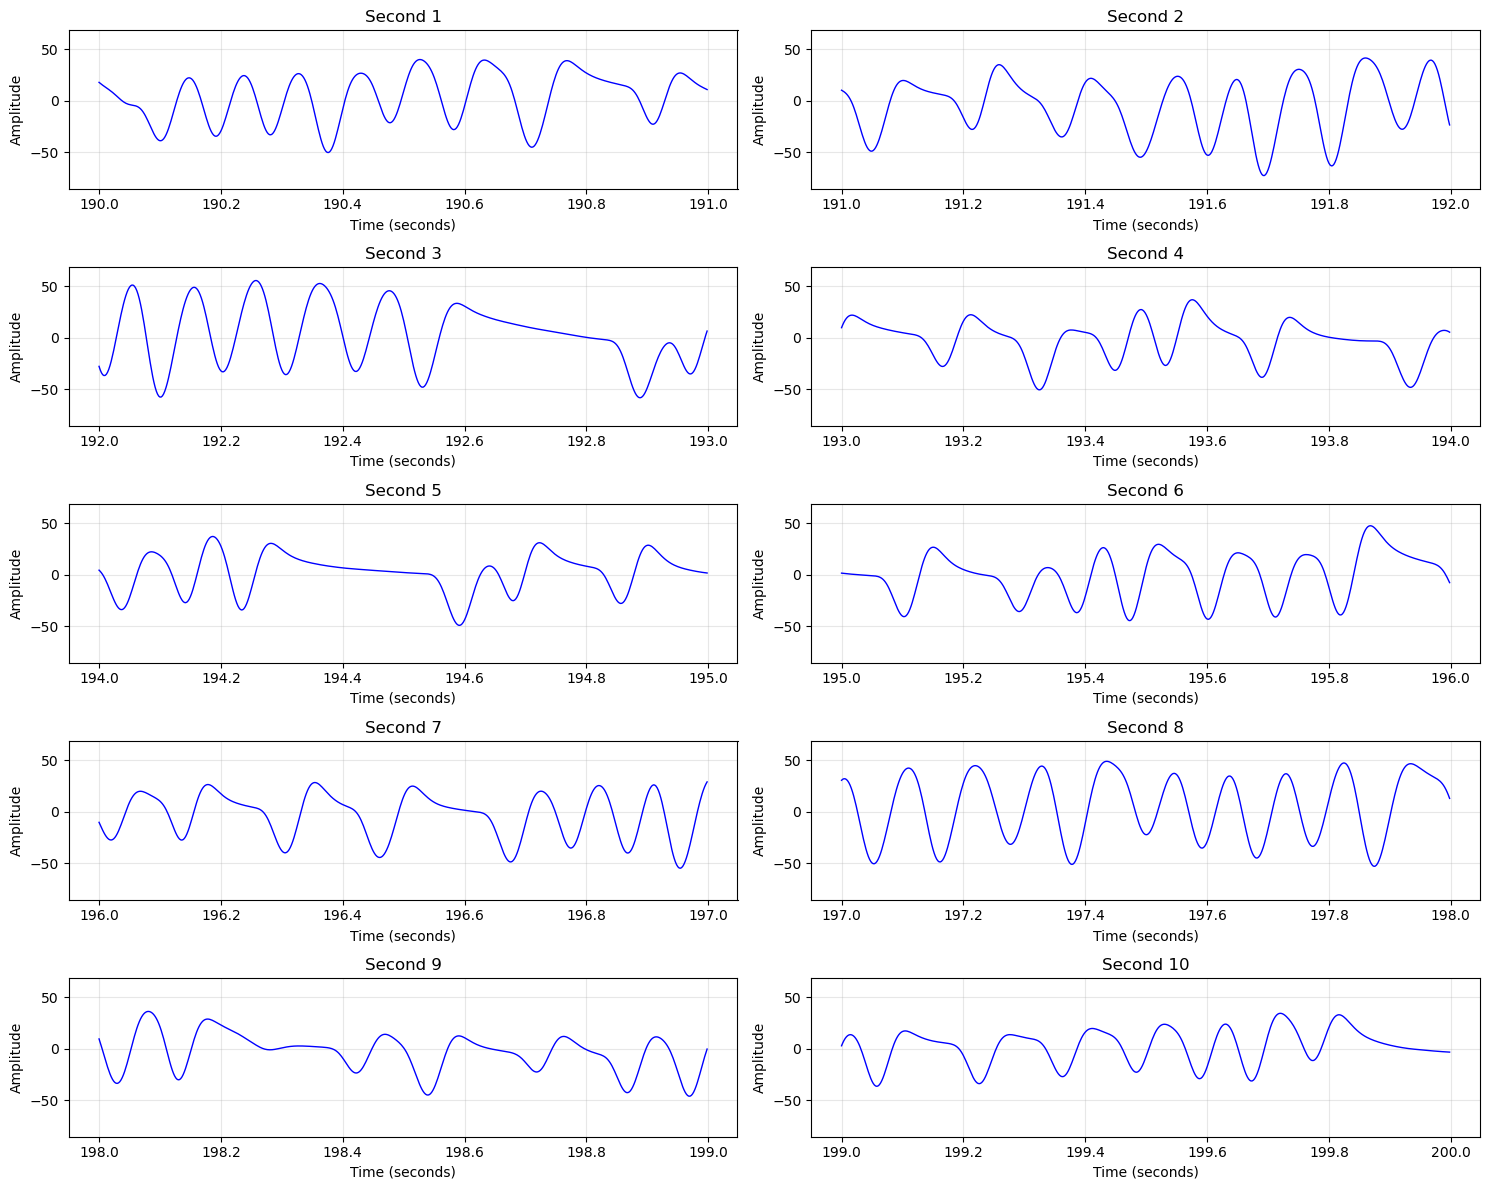

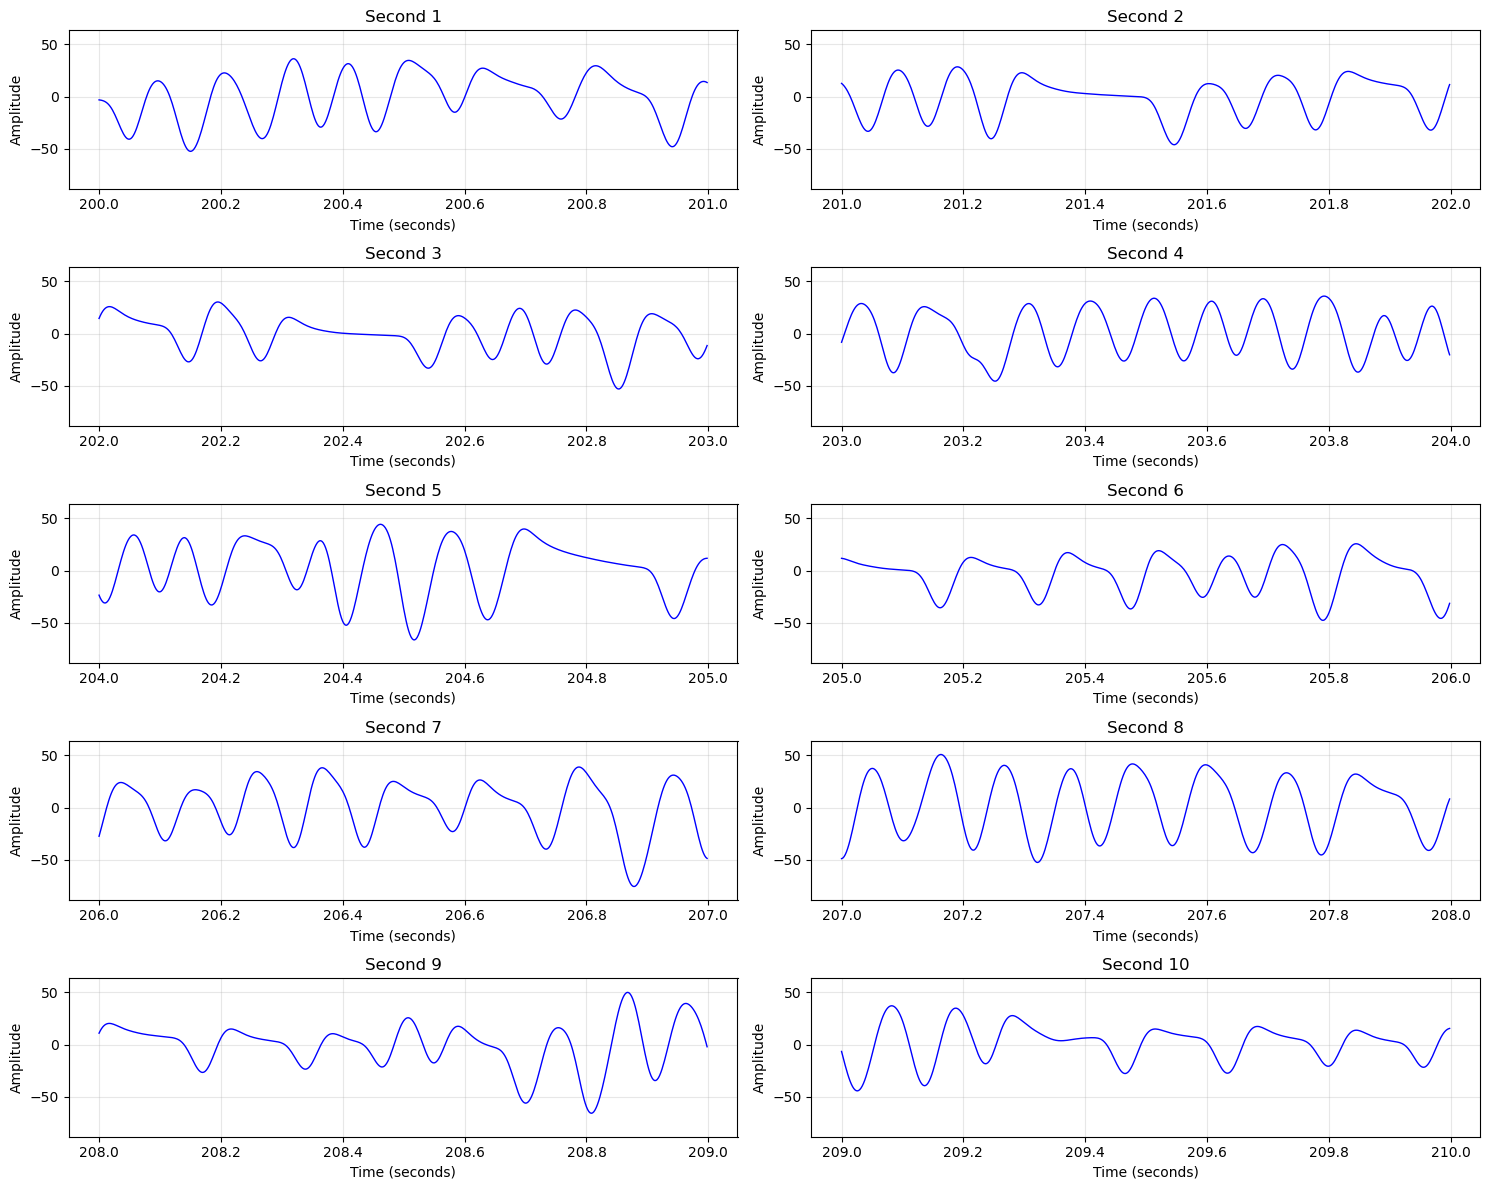

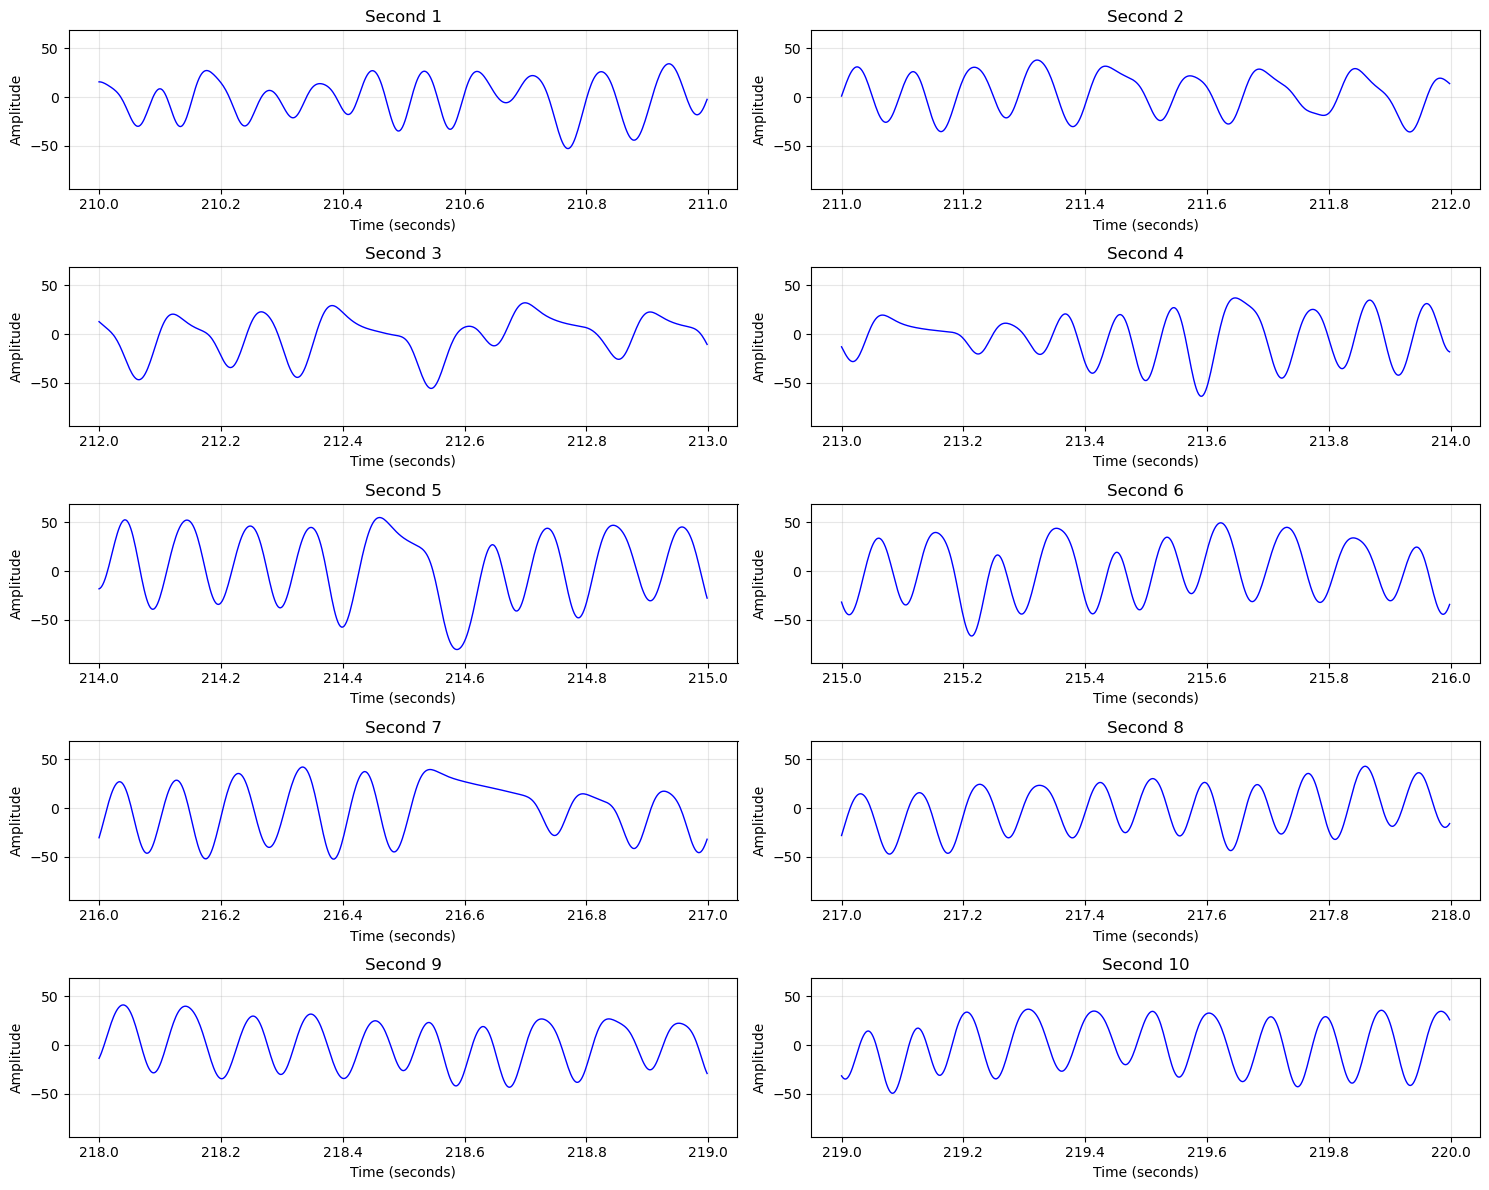

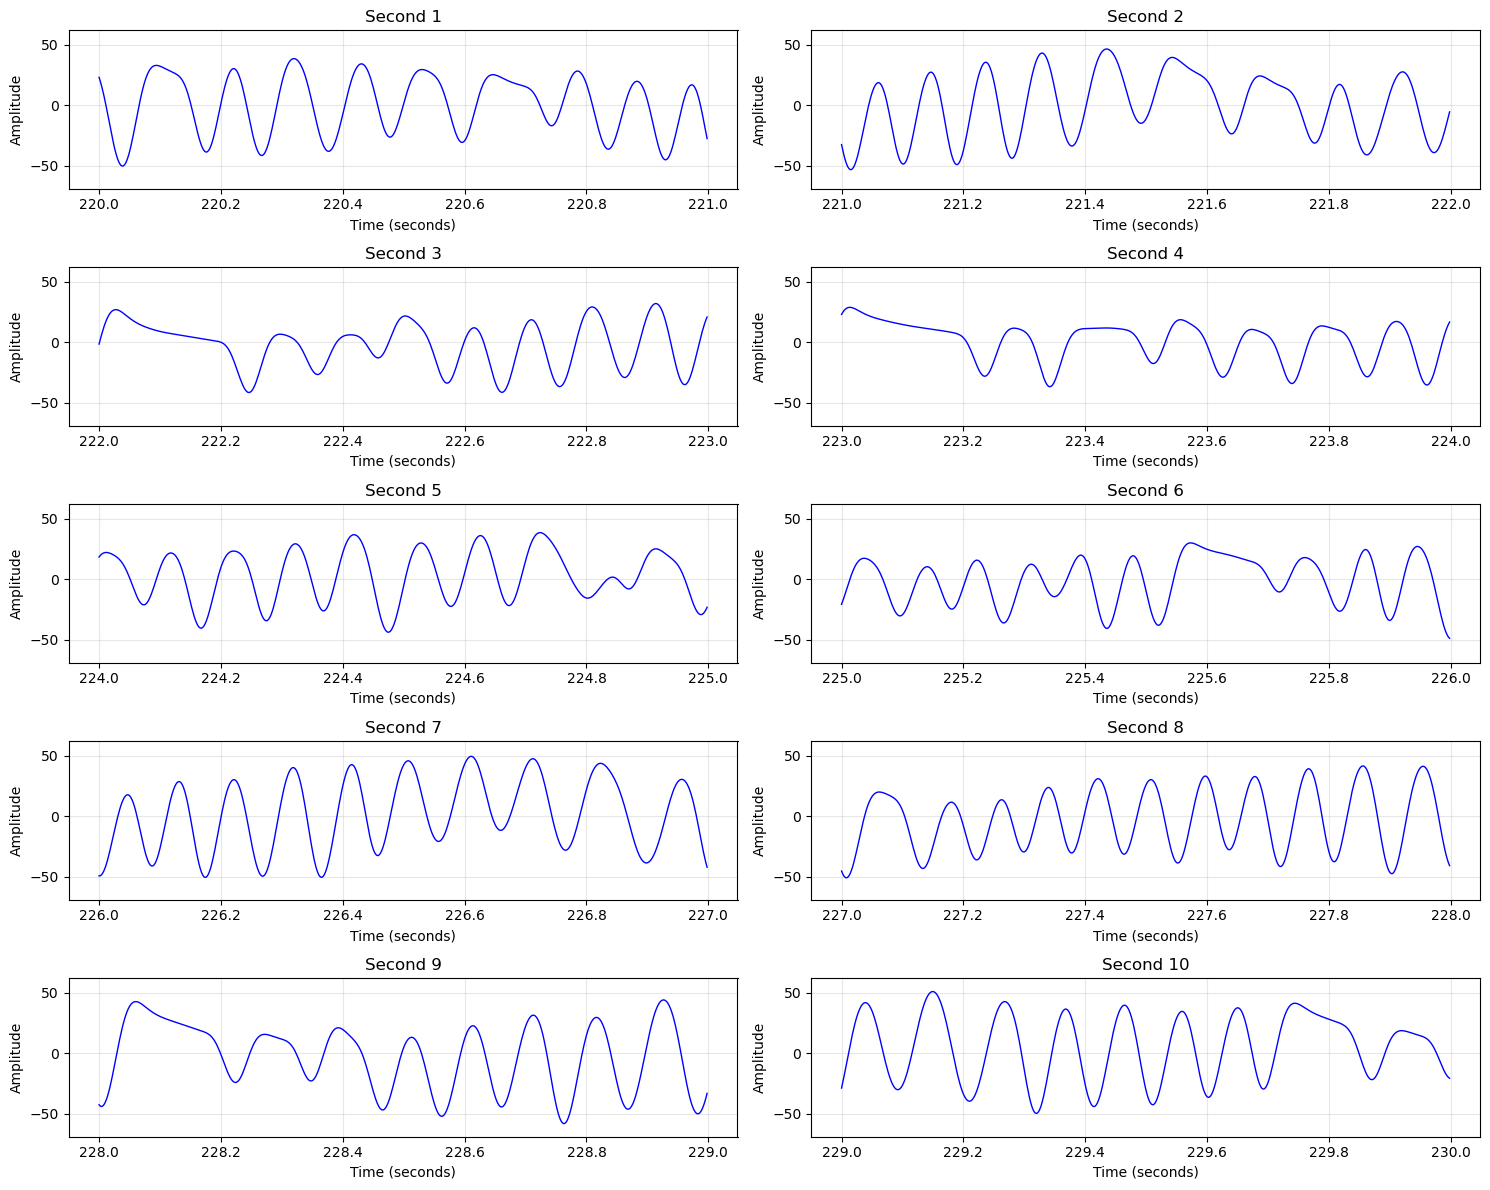

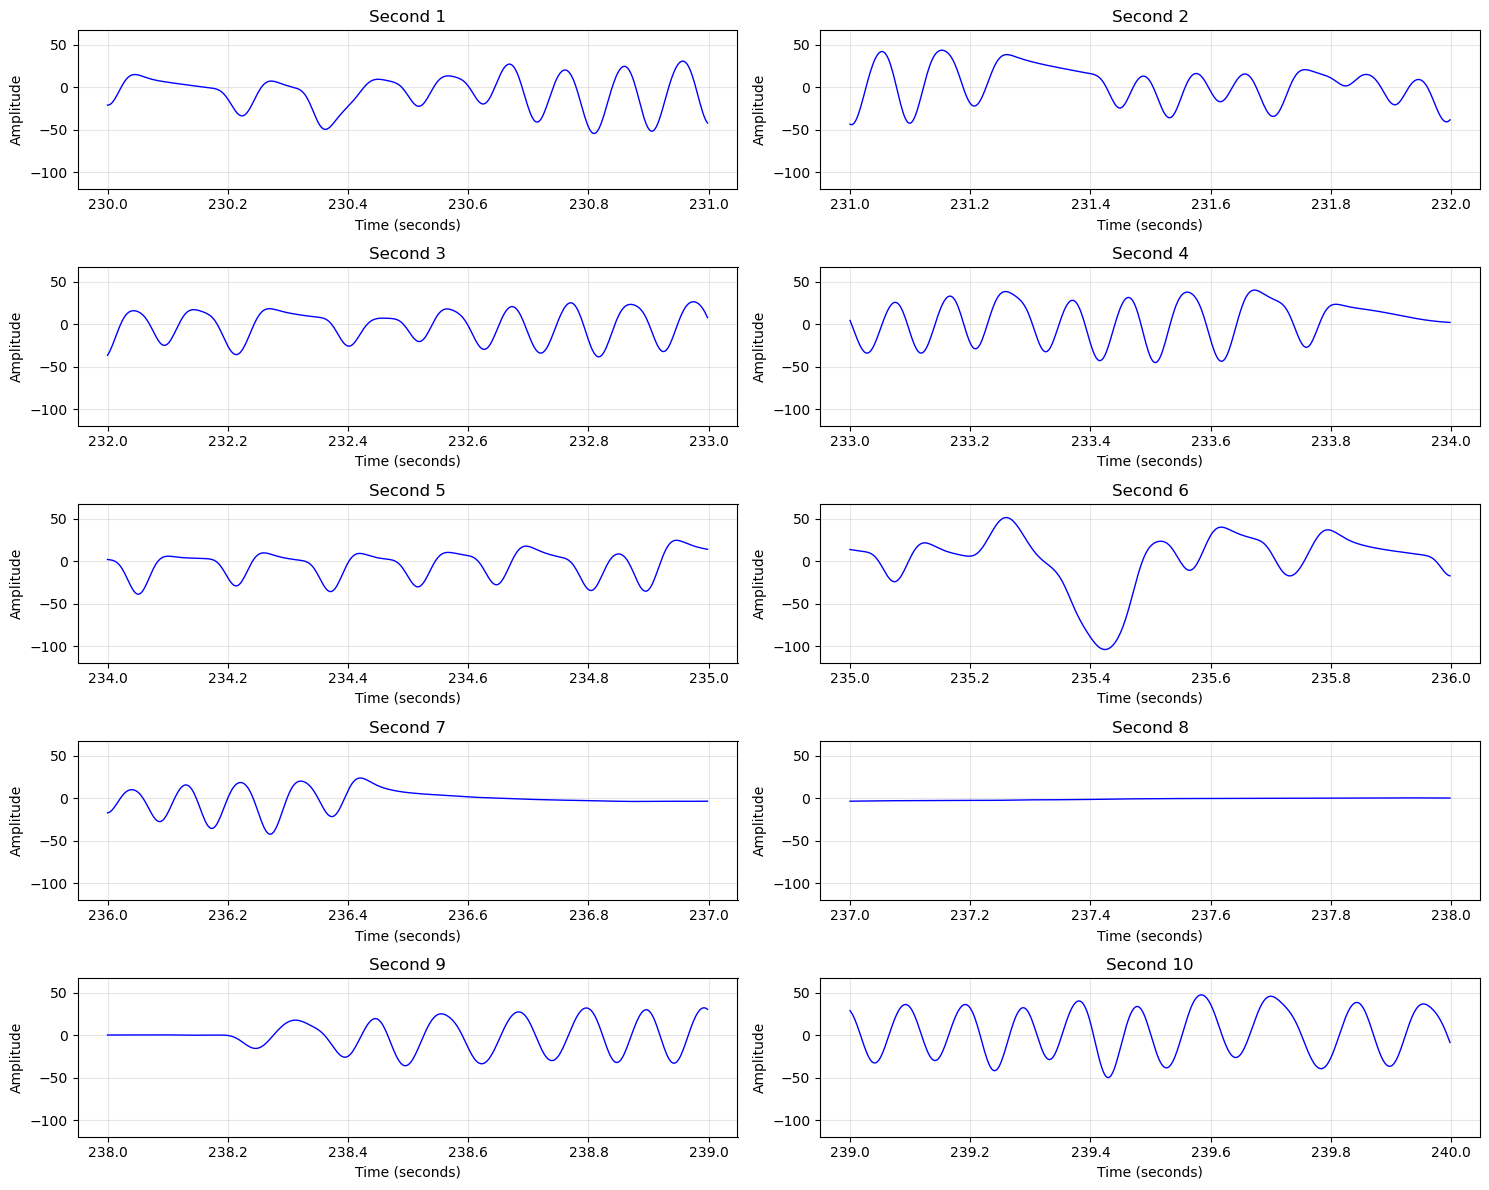

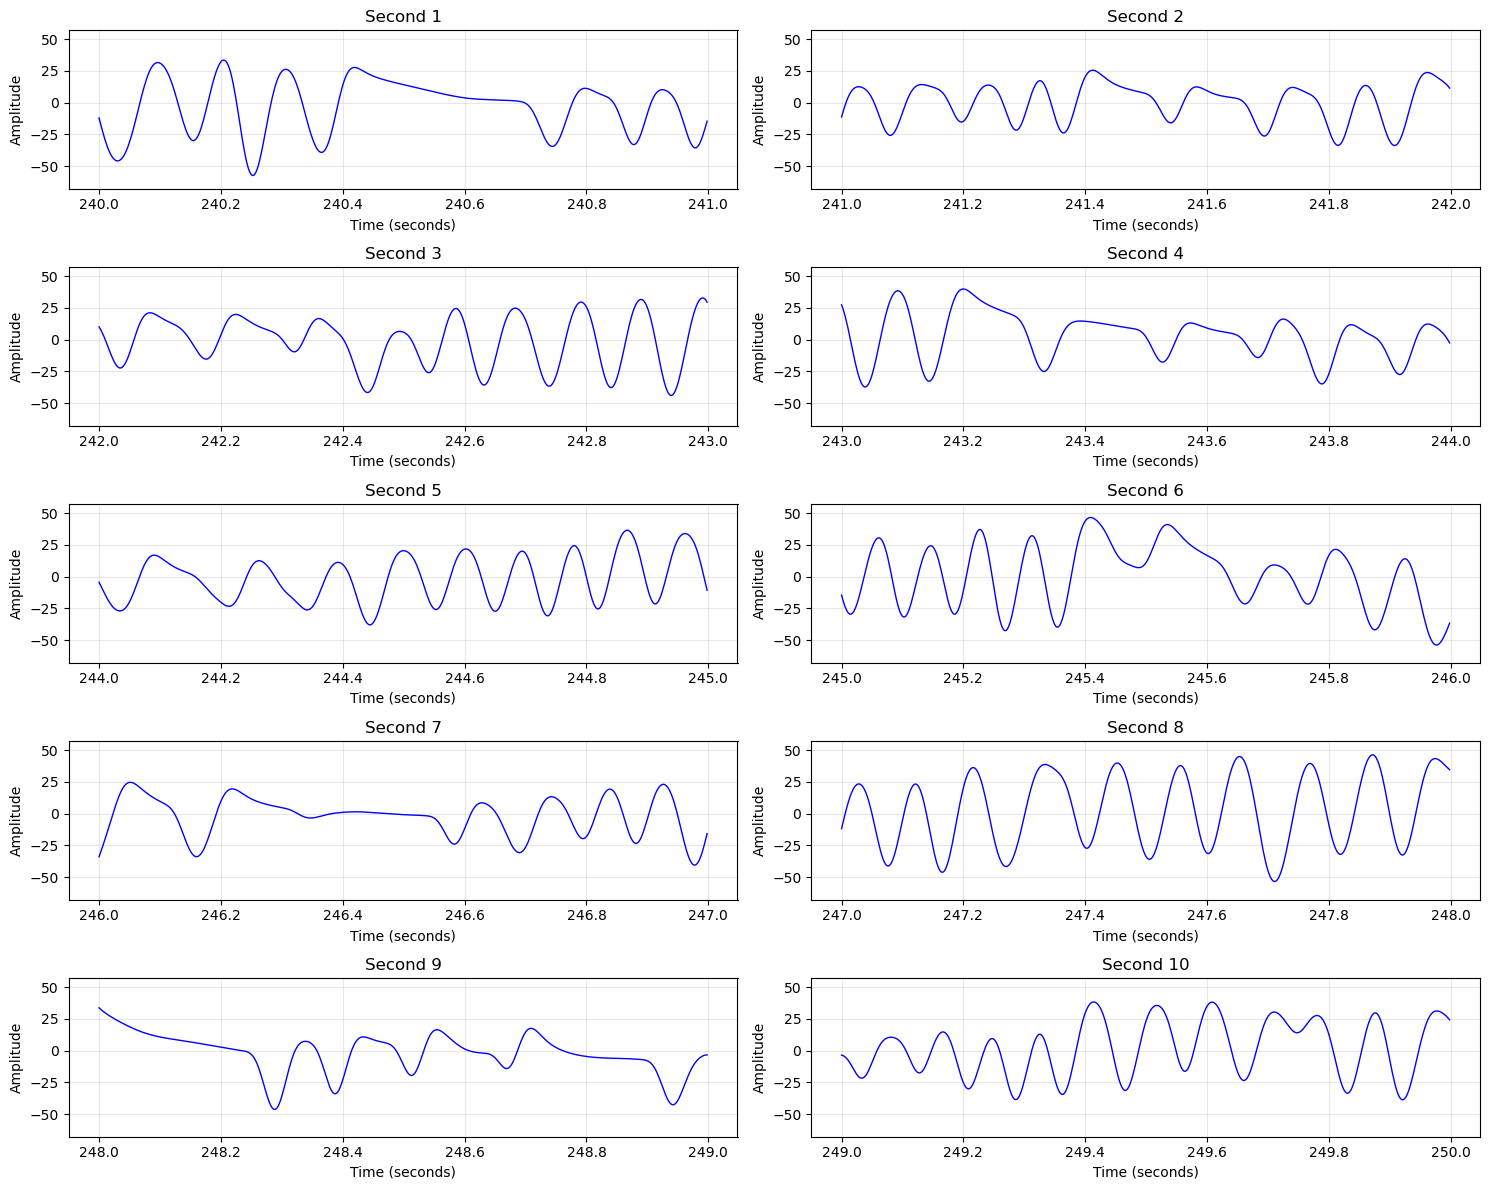

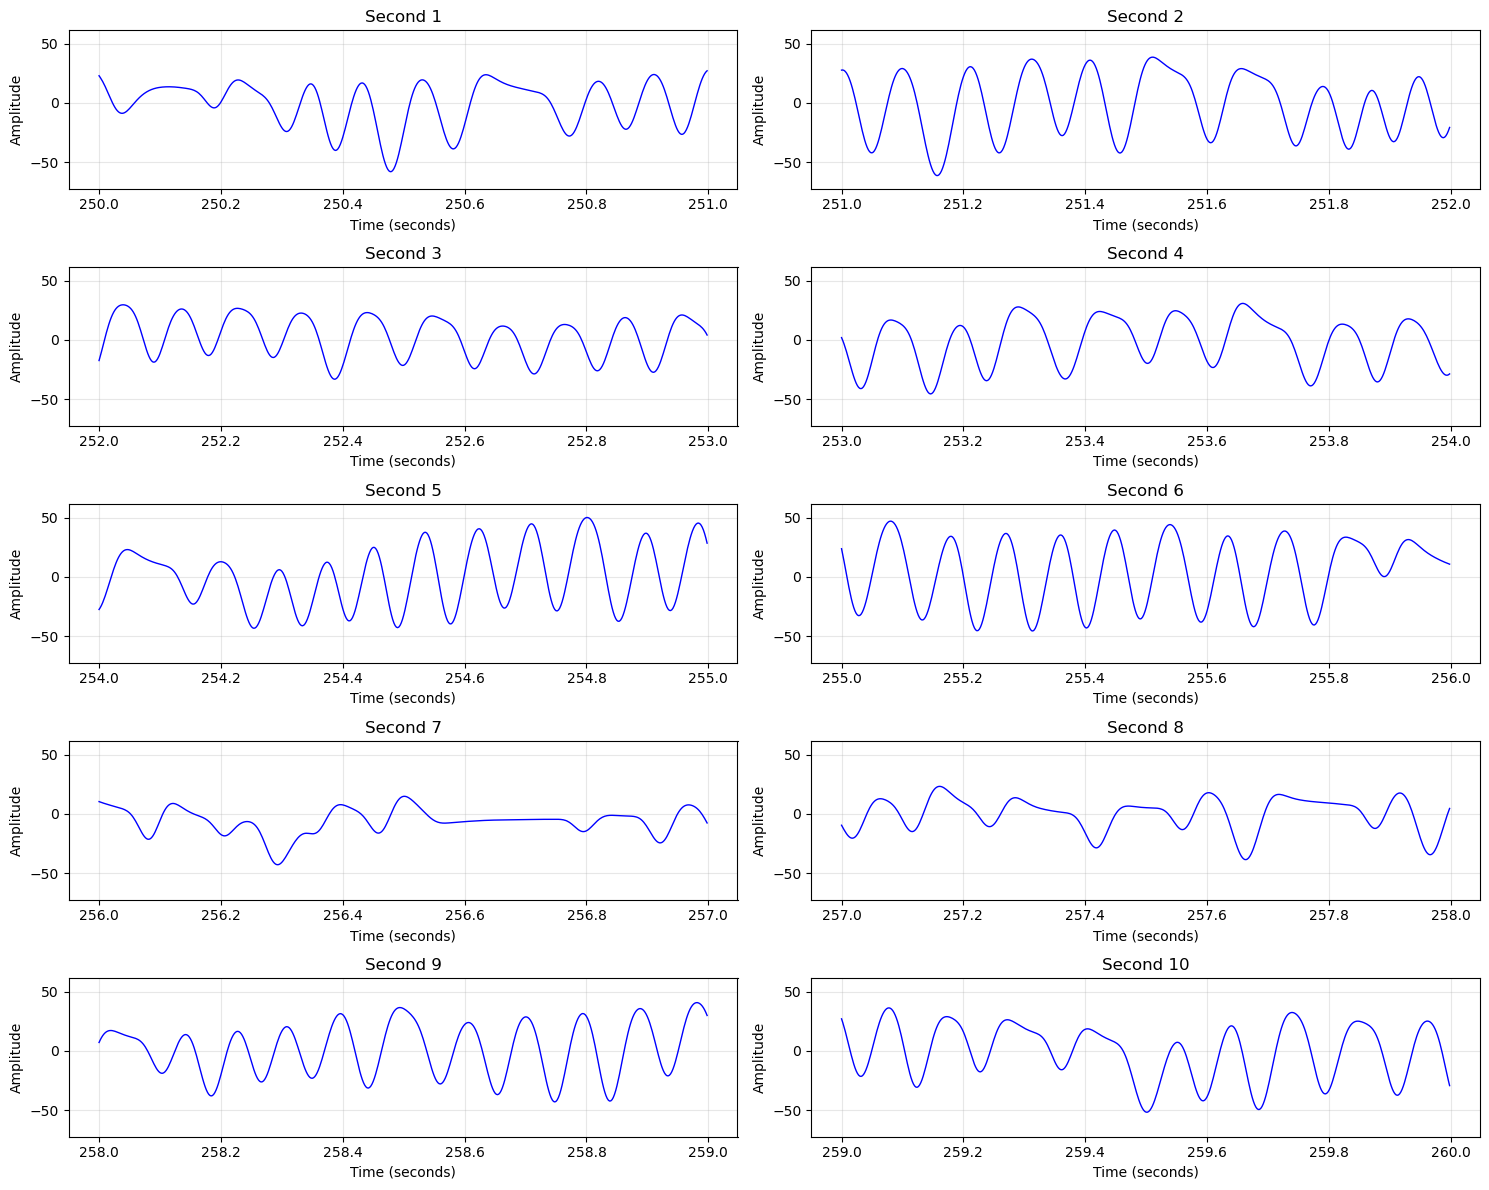

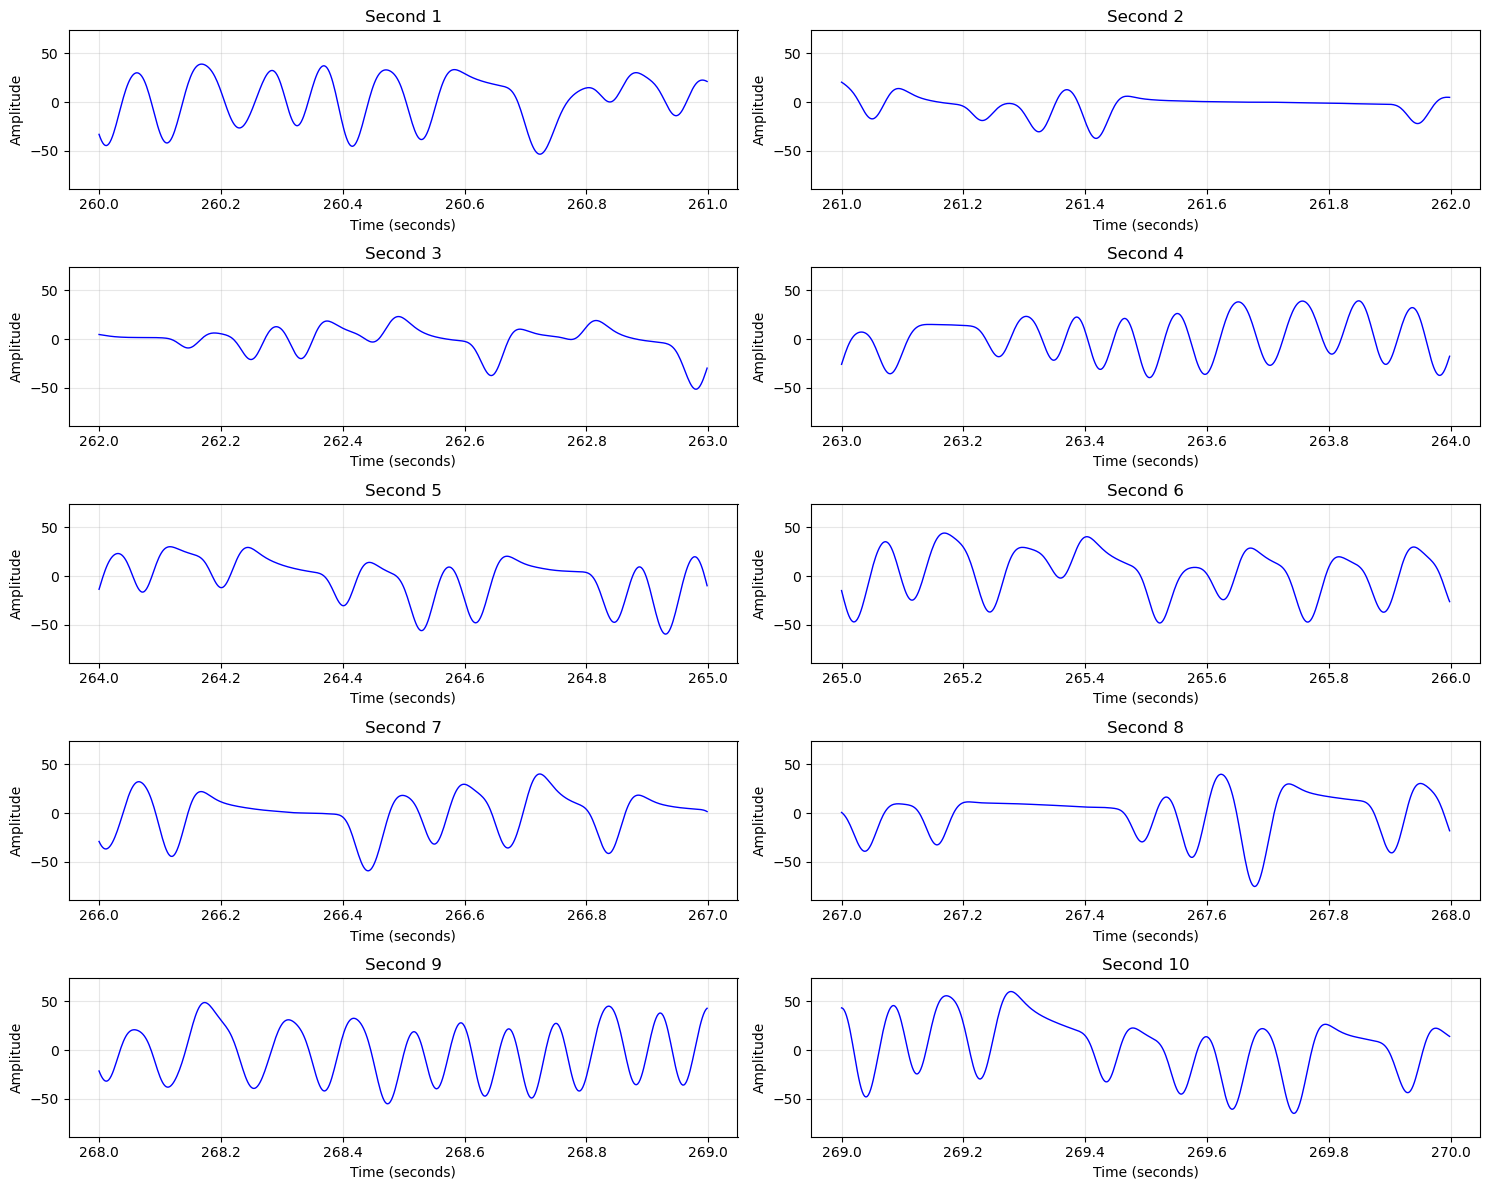

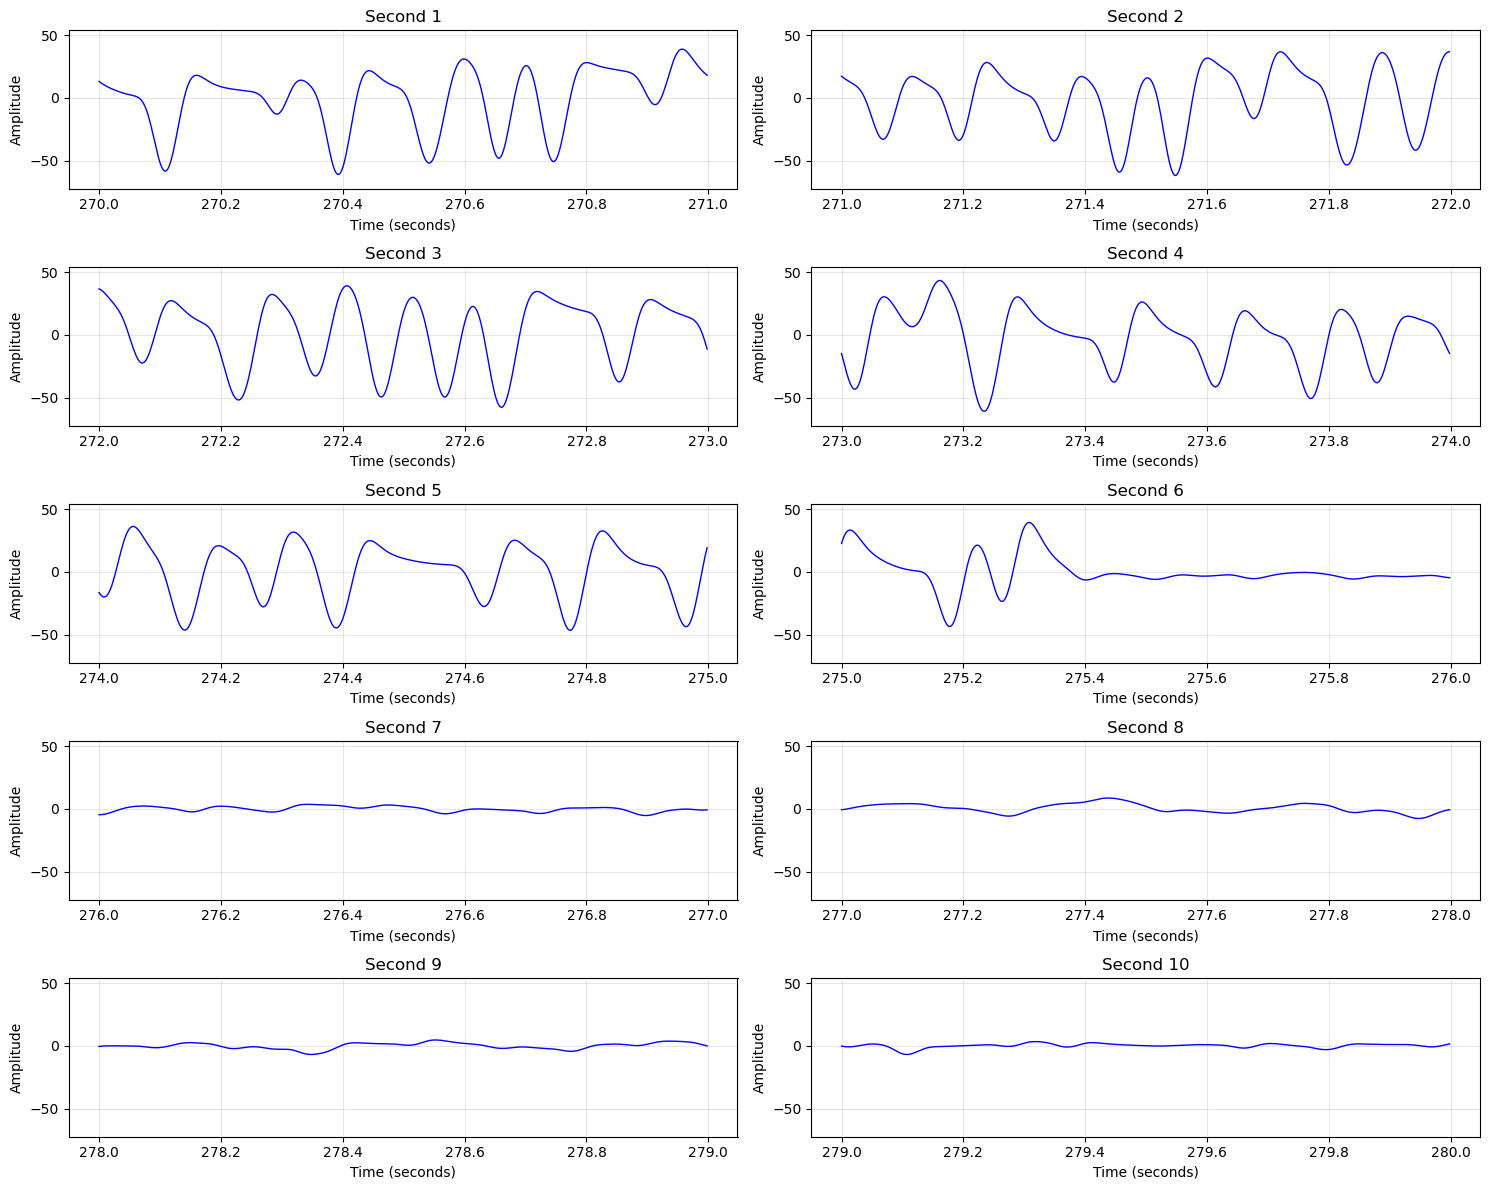

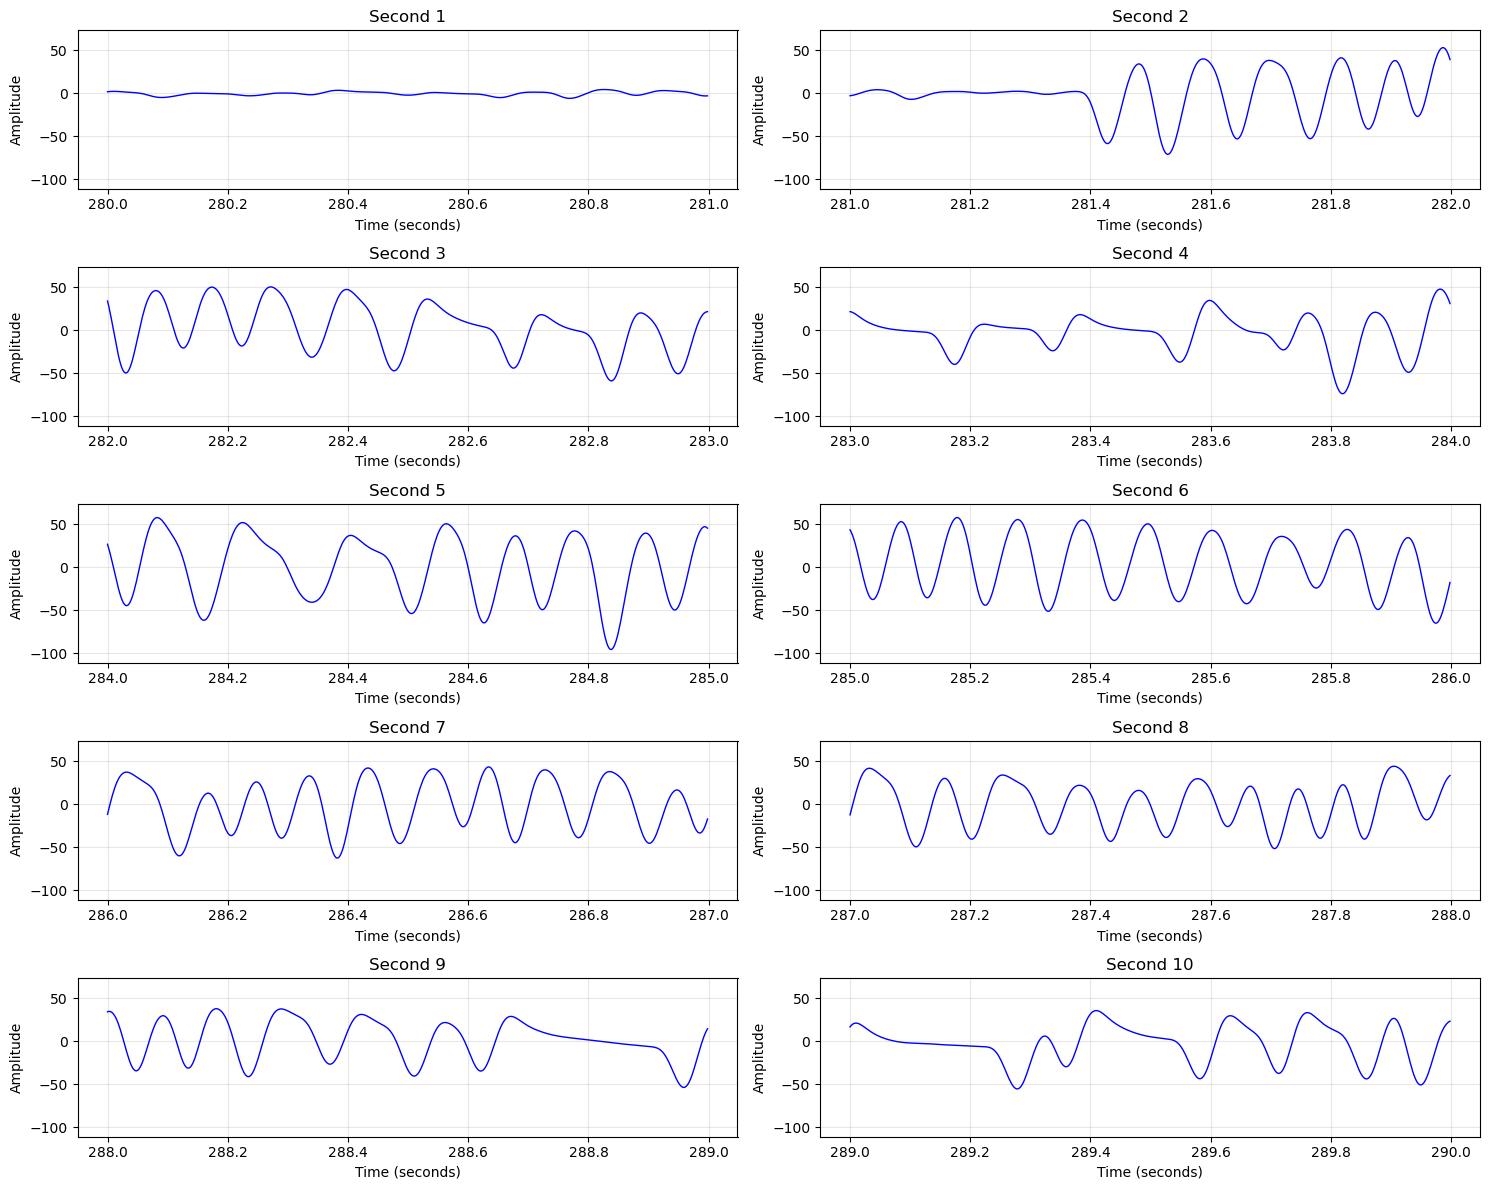

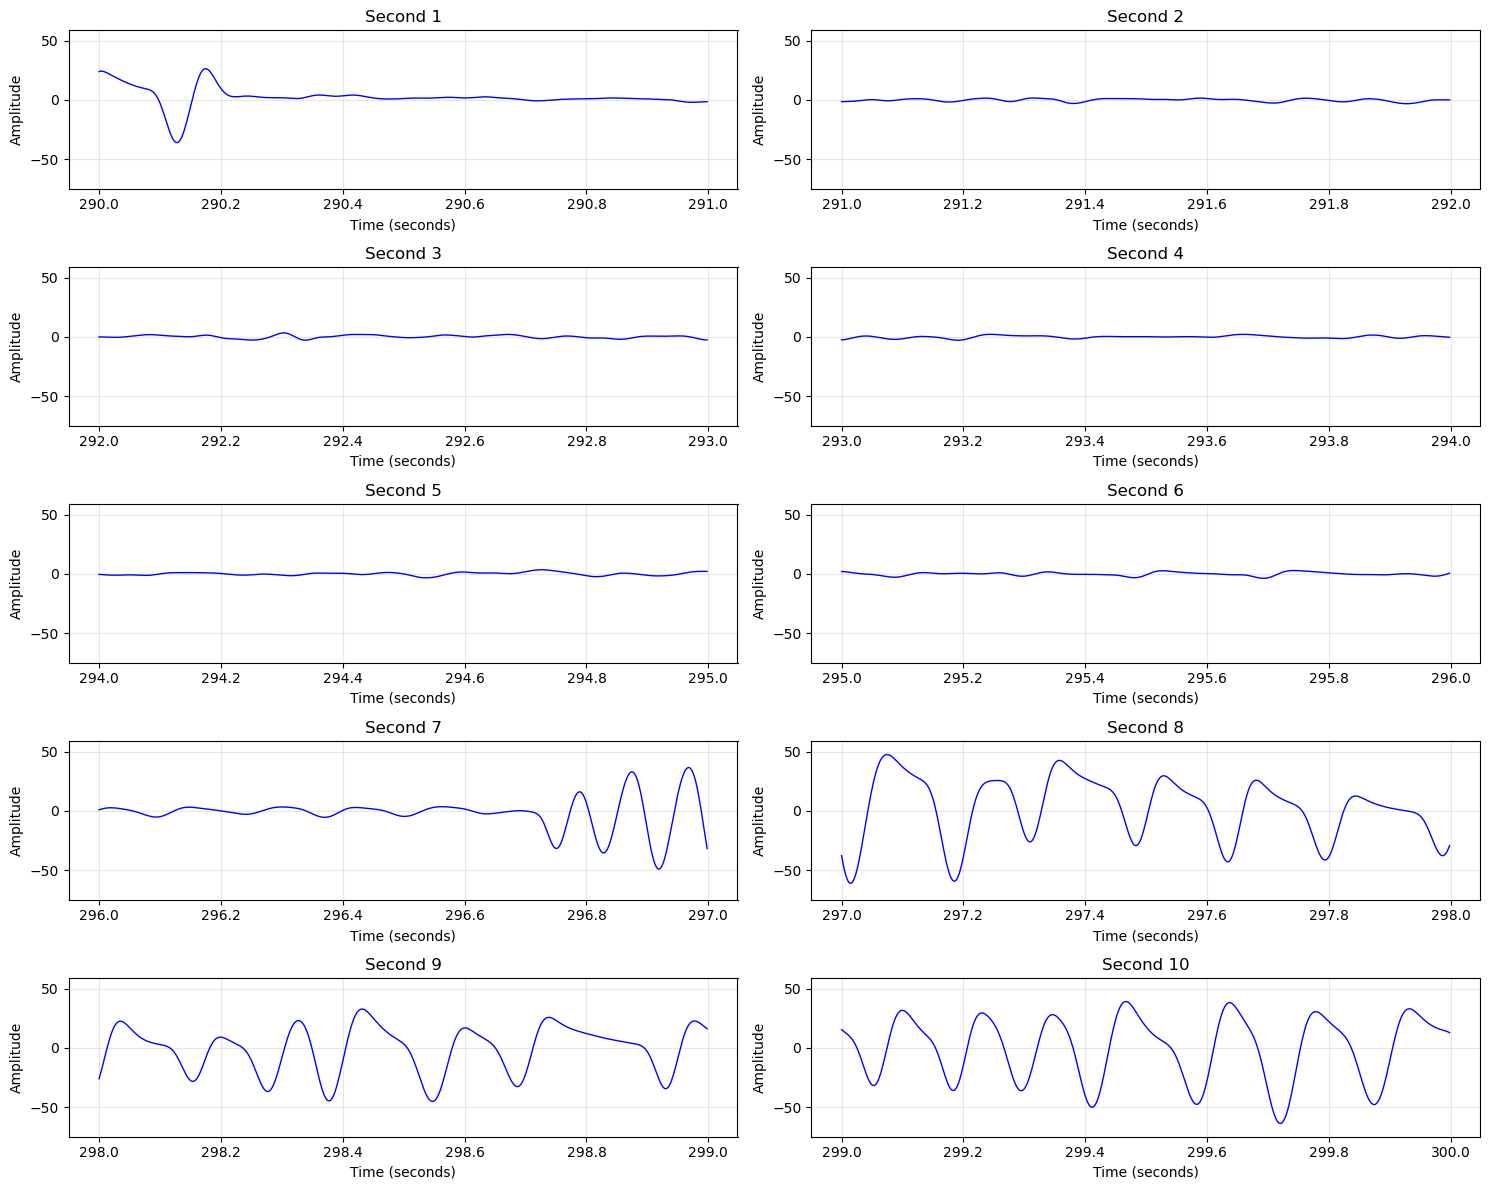

In [1]:
# Import necessary libraries
import tdt
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sp
import importlib
import resp_plotting


# Load TDT data
tdt_path = r"E:\resp_test_data\subj11-250227-070534"
mouse = tdt.read_block(tdt_path)

# Extract respiratory stream
resp_stream = mouse.streams['Resp']
resp_data = resp_stream.data
fs_original = resp_stream.fs  # Original sampling rate
start_time = resp_stream.start_time

# Apply amplification (100x)
resp_data = resp_data * 100  

# Apply low-pass filtering (100 Hz cutoff)
def lowpass_filter(data, fs, cutoff=100):
    """Applies a low-pass Butterworth filter."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = sp.butter(2, normal_cutoff, btype='low', analog=False)
    return sp.filtfilt(b, a, data)

resp_filtered = lowpass_filter(resp_data, fs_original, cutoff=100)

# Resample to 500 Hz
fs_target = 500  # Target sampling rate
num_samples = int(len(resp_filtered) * fs_target / fs_original)
resp_resampled = sp.resample(resp_filtered, num_samples)

# Plot filtered and resampled respiratory data
def plot_resp_signal(data, fs, start_time, duration=115):
    """Plots the respiratory signal for a given duration (in seconds)."""
    n_samples = int(duration * fs)
    time = np.arange(n_samples) / fs + start_time

    plt.figure(figsize=(12, 6))
    plt.plot(time, data[:n_samples], 'b-', linewidth=1)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(f'Respiratory Data - Filtered & Resampled')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_resp_signal(resp_resampled, fs_target, start_time)

# Peak detection
def detect_peaks(signal, fs):
    """Finds peaks in the respiratory signal."""
    min_breath_interval = 1 / 15  # Minimum 15 Hz (about 900 BPM max)
    min_distance = int(min_breath_interval * fs)

    peak_inds, _ = sp.find_peaks(signal, height=0, distance=min_distance)
    return peak_inds

peak_inds = detect_peaks(resp_resampled, fs_target)
peak_times = peak_inds / fs_target + start_time
peak_mags = resp_resampled[peak_inds]

# Compute breathing rate
def compute_breathing_rate(peak_times):
    """Calculates breathing rate from peak times."""
    peak_intervals = np.diff(peak_times)
    breathing_rate_hz = 1 / np.mean(peak_intervals)
    breathing_rate_bpm = breathing_rate_hz * 60

    print(f"Estimated Breathing Rate: {breathing_rate_bpm:.2f} breaths per minute")
    print(f"Estimated Breathing Rate: {breathing_rate_hz:.2f} breaths per second")
    return breathing_rate_bpm, breathing_rate_hz

breathing_rate_bpm, breathing_rate_hz = compute_breathing_rate(peak_times)

# Plot detected peaks
def plot_detected_peaks(time, signal, peak_times, peak_mags):
    """Plots respiratory signal with detected peaks."""
    plt.figure(figsize=(12, 6))
    plt.plot(time, signal, 'b-', linewidth=1, label="Respiratory Signal")
    plt.scatter(peak_times, peak_mags, color='red', marker='o', label="Detected Peaks")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title('Respiratory Data - Detected Peaks')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_detected_peaks(np.arange(len(resp_resampled)) / fs_target + start_time, resp_resampled, peak_times, peak_mags)

# Reload plotting module and plot by 10-second chunks
importlib.reload(resp_plotting)

chunk_size = 10  # seconds
n_samples_per_chunk = int(chunk_size * fs_target)

for i in range(len(resp_resampled) // n_samples_per_chunk):
    start_idx = i * n_samples_per_chunk
    end_idx = start_idx + n_samples_per_chunk
    rsp_chunk = resp_resampled[start_idx:end_idx]

    # Use your custom plotting function
    resp_plotting.plot_respiratory_data_by_second(rsp_chunk, fs_target, start_time=start_time + i * chunk_size)

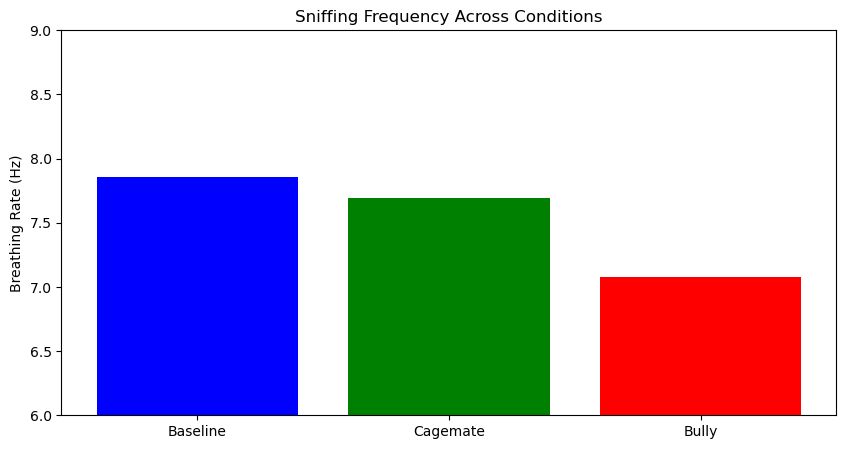

In [2]:
plt.figure(figsize=(10, 5))
plt.bar(["Baseline", "Cagemate", "Bully"], [7.86, 7.69, 7.08], color=["blue", "green", "red"])
plt.ylabel("Breathing Rate (Hz)")
plt.title("Sniffing Frequency Across Conditions")
plt.ylim(6, 9)  # Keep axis focused on relevant range
plt.show()
